# Figures for the paper

Regenerated **2026-07-14** on the public `MatImba.analysis` module. The plotting code
is identical to the original notebook (backup: `Final_figs_backup_2026-07-14.ipynb`),
so every figure is reproduced exactly; what changed is the data layer:

- packaged `use_matimba_style()` replaces the hard-coded mplstyle path (Referee 2);
- the deprecated `MatImba.analyser` stack (`analyse_dataset` / `imba_analyser` /
  `evaluate_ckpt`) is replaced by `PredictionSet` / `collect` / `discovery_metrics` /
  `summary_plot`, with a thin `FoldAnalyser` adapter exposing the old interface to the
  untouched plotting functions;
- one bad-run filter drives everything: trajectory-health screening
  (`filter_outlier_runs`, defined in the Fig 2 section) applied to the run index, plus
  prediction-level `filter_bad_runs` for the legacy npz runs without val_logs;
- metric tables use ddof = 1 and significant-figure formatting (Referees 2, 3);
- legacy npz metrics are recomputed from raw arrays under `SERA_T0 = 0.5`.

Run top-to-bottom; outputs land in `figs/paper_final/` and `results/`.


## Loading packages and setups

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import torch
torch.use_deterministic_algorithms(True)

In [2]:
import io
import numpy as np
import pandas as pd
import palettable as pt
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.offsetbox import AnchoredText

In [3]:
# Packaged style + the public analysis API (replaces the hard-coded
# /data/llei/... mplstyle path and the deprecated MatImba.analyser imports)
from MatImba.analysis import (
    DatasetProfile,
    EnsemblePrediction,
    PredictionSet,
    aggregate,
    compare_profiles,
    discover_runs,
    discovery_metrics,
    filter_bad_runs,
    formatted_table,
    load_predictions,
    metrics_table,
    summary_plot,
    use_matimba_style,
)
from MatImba.analysis.report import to_latex_bold_best

use_matimba_style()
os.makedirs("figs/paper_final", exist_ok=True)
os.makedirs("results", exist_ok=True)


/gpfs01/home/ezzll3/chemsoft/mace/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from MatImba.utils import fd_optimal_bins
from MatImba.dataset import calc_dil, calc_comprehensive_imbalance

Helper functions

In [5]:
import string
# Function to add the label consistently
def add_panel_label(ax, index, loc = (-0.1, 1.1), alphabet = string.ascii_lowercase):
    
    ax.text(*loc, f"{alphabet[index]}", 
            transform=ax.transAxes, 
            fontsize=10, va='top', ha='right')

## Fig 1. Distribution imbalance level of Matbench datasets

In [6]:
datasets = [
    'matbench_dielectric', 
    'matbench_jdft2d', 
    'matbench_steels', 
    'matbench_expt_gap', 
    'matbench_phonons',
    'matbench_log_gvrh',
    'matbench_log_kvrh',
    'matbench_glass', 
    'matbench_expt_is_metal',
    'matbench_perovskites',
    'matbench_mp_e_form',
    'matbench_mp_gap',
    'matbench_mp_is_metal',
]

In [7]:
def get_tarcol(df):
    return list(df)[-1]


def is_classification(folder):
    return folder in {'matbench_expt_is_metal', 'matbench_mp_is_metal', 'matbench_glass'}
regressions = [dataset for dataset in datasets if not is_classification(dataset)]
labels = [dataset.split('_', 1)[-1] for dataset in regressions]


def plot_distribution_with_metrics(
    data: np.ndarray, 
    ax: plt.Axes, 
    label: str = None, 
    show_kde: bool = True
) -> None:
    """
    Plots a histogram with Robust DIL metrics.
    Robust against non-numeric/missing data (Fixes TypeError).
    """
    # 1. Robust Data Cleaning
    # Flatten array
    raw_data = np.asarray(data).flatten()
    
    # FIX: Force conversion to numeric (float). 
    # 'coerce' turns strings/errors into NaNs, preventing crashes.
    clean_data = pd.to_numeric(raw_data, errors='coerce')
    
    # Now safe to check for NaNs
    data = clean_data[~np.isnan(clean_data)]
    
    if len(data) == 0:
        ax.text(0.5, 0.5, "No Valid Data", ha='center', va='center')
        return

    # 2. Plot Histogram
    counts, bins, patches = ax.hist(
        data, 
        bins='fd', 
        density=False, 
        color='#4393c3', 
        alpha=0.65, 
        edgecolor='None', 
        linewidth=0.5
    )
    
    # 3. (Optional) Add KDE curve
    if show_kde and len(data) > 1 and np.var(data) > 0:
        try:
            density = gaussian_kde(data)
            # Plot over actual data range
            xs = np.linspace(min(data), max(data), 200)
            ax.plot(xs, density(xs), color='#1f4e79', lw=1.5, label='KDE')
        except Exception:
            pass # Skip KDE if singular matrix (e.g. all values same)

    # 4. Calculate Metrics
    metrics = calc_comprehensive_imbalance(data)
    
    # 5. Create Text Box
    stats_text = (
        f"{label}\n"
        f"$h$: {metrics['DIL']: .3f}\n"
        # f"$G$: {metrics['Gini']: .3f}\n"
        f"$W_1$: {metrics['Wasserstein']: .3f}"
    )
    
    at = AnchoredText(
        stats_text,
        prop=dict(size=8, family='monospace'), 
        frameon=True,
        loc='upper right'
    )
    at.patch.set_boxstyle("round,pad=0.1,rounding_size=0.2")
    at.patch.set_alpha(0.25)
    at.patch.set_edgecolor('#d3d3d3')
    ax.add_artist(at)
    
    # 6. Formatting
    # ax.set_ylabel("Density")
    # ax.set_xlabel(label if label else "Target Value")

    return 

In [8]:
for i, (label, dataset) in enumerate(zip(labels, regressions)):
    globals()[label] = pd.read_csv(f'matbench_data/{label}.csv')
    target_col = get_tarcol(globals()[label])
    raw_data = np.asarray(globals()[label][[target_col]]).flatten()
    
    # Force conversion to numeric (float). 
    # 'coerce' turns strings/errors into NaNs, preventing crashes.
    clean_data = pd.to_numeric(raw_data, errors='coerce')
    
    # Now safe to check for NaNs
    data = clean_data[~np.isnan(clean_data)]
    metrics = calc_comprehensive_imbalance(data)
    metrics.update({'dataset':label, 'size': len(data)})
    
    if i==0:
        result_df = pd.DataFrame([metrics])
    else:
        result_df.loc[len(result_df)] = metrics

result_df = result_df[['dataset', 'size', 'DIL', 'Gini', 'KL_Div', 'Wasserstein']]
# result_df.to_csv('matbench_data/matbench_stats.csv', index = None)

In [9]:
from adjustText import adjust_text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

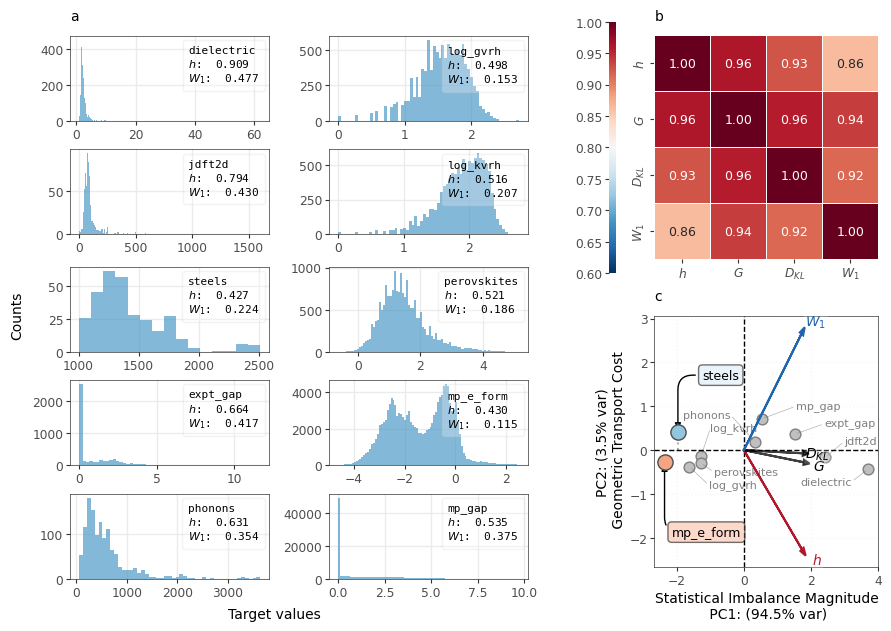

In [10]:
# --- 2. Your Plotting Code ---

fig = plt.figure(figsize=(8.8, 6.2), layout='compressed')
subfigs = fig.subfigures(1, 2, width_ratios=[3.2, 2])

# --- First Subfigure: Columns 1 & 2 ---
gs_left = subfigs[0].add_gridspec(5, 2)

hst_axes = []
for col in range(2):
    for row in range(5):
        ax = subfigs[0].add_subplot(gs_left[row, col])
        hst_axes.append(ax)

# Assuming labels and regressions are defined in your environment
for label, dataset, ax in zip(labels, regressions, hst_axes):
    data = globals()[label].values
    plot_distribution_with_metrics(data, ax=ax, label=label)

subfigs[0].supxlabel('Target values', fontsize=10)
subfigs[0].supylabel('Counts', fontsize=10)
hst_axes[0].set_title('a', loc='left', fontsize=10)

# --- Second Subfigure: Column 3 ---
gs_right = subfigs[1].add_gridspec(2, 1)

df = result_df.rename(columns={'DIL': r'$h$', 'Gini': r'$G$', 'KL_Div': r'$D_{KL}$', 'Wasserstein': r'$W_1$'})
metrics = [r'$h$', r'$G$', r'$D_{KL}$', r'$W_1$']

cor_ax = subfigs[1].add_subplot(gs_right[0, 0])
corr_matrix = df[metrics].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', 
            vmin=0.6, vmax=1, square=True, linewidths=0.5, cbar=True, 
            ax=cor_ax, annot_kws={"size": 9}, cbar_kws={
                "shrink": 1.0, "pad": -0.09, "aspect": 40, "location": "left", 
            })

cor_ax.set_title('b', loc='left', fontsize=10)

pca_ax = subfigs[1].add_subplot(gs_right[1, 0])

X = df[metrics]

# Normalize & PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
loadings = pca.components_.T

# Plot Datasets (Scatter)
texts = []
x_coords = []
y_coords = []
obstacle_points = [] 

for i, row in df.iterrows():
    name = row['dataset']
    x, y = coords[i, 0], coords[i, 1]
    
    obstacle_points.append([x, y])
    
    if name == 'steels':
        pca_ax.scatter(x, y, s=120, c='#92c5de', edgecolors='#4d4d4d', zorder=10)
        pca_ax.annotate(name, xy=(x, y), xytext=(x+1.28, y+1.3), fontsize=9, va='center', ha='center', 
                    arrowprops=dict(arrowstyle="-|>", connectionstyle="angle,angleA=0,angleB=90,rad=15"),
                    bbox=dict(boxstyle="round", fc="#dceaf6", ec="#000000", alpha=0.55))
        pca_ax.plot([x, x], [0, y], 'k:', alpha=0.3)

    elif name == 'mp_e_form':
        pca_ax.scatter(x, y, s=120, c='#f4a582', edgecolors='#4d4d4d', zorder=10)
        pca_ax.annotate(
            name, xy=(x, y), xytext=(x+1.25, y-1.6), fontsize=9, va='center', ha='center',
            bbox=dict(boxstyle="round", fc="#fcbba1", ec="#000000", alpha=0.55),
            arrowprops=dict(
                arrowstyle="-|>", connectionstyle="angle,angleA=0,angleB=90,rad=15"
            )
        )
        pca_ax.plot([x, x], [0, y], 'k:', alpha=0.3)
        
    else:
        # Background datasets
        pca_ax.scatter(x, y, s=60, c='silver', edgecolors='tab:gray')
        t = pca_ax.text(x, y, name, fontsize=8, alpha=0.5)
        texts.append(t)
        
        x_coords.append(x)
        y_coords.append(y)

optimised_coords=(
	(3.22, -0.72),
	(3.0, 0.2),
	(2.4, 0.6),
	(-0.4, 0.8),
	(-1.05, -0.8),
	(-1.0, 0.5),
	(-0.9, -0.5),
	(1.55, 1.0),
)

# Apply coordinates and draw connecting lines
for t, new_coord, orig_x, orig_y in zip(texts, optimised_coords, x_coords, y_coords):
    new_x, new_y = new_coord
    
    if new_x < orig_x:
        t.set_horizontalalignment('right')
    else:
        t.set_horizontalalignment('left')
        
    t.set_verticalalignment('center')
    t.set_position((new_x, new_y))
    
    # Draw arrow from the text back to the original point
    pca_ax.annotate('', xy=(orig_x, orig_y), xytext=(new_x, new_y),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6),
                    va='center', ha='center', zorder=1)
# ----------------------------------

# Axis Styling
pca_ax.axhline(0, color='k', lw=1, ls='--')
pca_ax.axvline(0, color='k', lw=1, ls='--')
pca_ax.set_xlabel(f"Statistical Imbalance Magnitude\n PC1: ({pca.explained_variance_ratio_[0]:.1%} var)", fontsize=10)
pca_ax.set_ylabel(f"PC2: ({pca.explained_variance_ratio_[1]:.1%} var)\n Geometric Transport Cost", fontsize=10)
pca_ax.grid(True, linestyle=':', alpha=0.4)

# Plot Vectors (Arrows)
scale = 3.5
for i, metric in enumerate(metrics):
    alpha = 1.0 if metric in [r'$h$', r'$W_1$'] else 0.75
    weight = 'bold' if metric in [r'$h$', r'$W_1$'] else 'normal'
    if metric == r'$W_1$':
        color = '#2166ac'
        tx, ty = loadings[i, 0]*scale*1.25, loadings[i, 1]*scale*1.1
        pca_ax.text(tx, ty, metric, color='#2166ac', ha='center', va='center', weight=weight, fontsize=10,
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.2), zorder=5)
    elif metric == r'$h$':
        color = '#b2182b'
        tx, ty = loadings[i, 0]*scale*1.25, loadings[i, 1]*scale*1.1
        pca_ax.text(tx, ty, metric, color='#b2182b', ha='center', va='center', weight=weight, fontsize=10,
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.2), zorder=5)
    else:
        color = 'k'
        tx, ty = loadings[i, 0]*scale*1.25, loadings[i, 1]*scale*1.35
        pca_ax.text(tx, ty, metric, color='k', ha='center', va='center', weight=weight, fontsize=10,
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.2), zorder=5)
    
    pca_ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale, 
         color=color, alpha=alpha, head_width=0.12, linewidth=1.5, zorder=5)

pca_ax.set_title('c', loc='left', fontsize=10)

plt.savefig('figs/paper_final/matbench_dil.jpg', dpi=600)

## Fig 2. Training trajectory

Defines the shared trajectory-health run filter (`filter_outlier_runs`) reused by every analysis below.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import math
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch
from scipy.stats import pearsonr, spearmanr, kendalltau
import palettable.colorbrewer.diverging as cbd

# ==========================================
# 1. ROBUST PER-FOLD FILTERING (UNIFIED)
# ==========================================
def filter_outlier_runs(dfs, method_label, fold_id, metric='mae', 
                        explode_ratio=100.0,     
                        conv_ratio=5.25,          
                        warmup_epochs=20,
                        explosion_warmup=35,
                        sera_explode_ratio=250.0):
    """
    Robustly filters runs ON A PER-FOLD BASIS using Relative metrics.

    The explosion checks (2, 3) start at `explosion_warmup` (default 35), later
    than the general `warmup_epochs`, so ordinary early-training transients that
    persist a few epochs past warmup do not disqualify otherwise-healthy runs.
    SERA uses its own multiplier `sera_explode_ratio` (default 250x vs 100x for
    MAE) because SERA is intrinsically far more volatile: marginal exceedances
    of the 100x bound (1.1-1.9x over, e.g. phonons MatFold fold 2) are ordinary
    transients, whereas genuine divergences overshoot by orders of magnitude
    (e.g. log_gvrh MatFold fold 1 at 300x-1e9x) and are still rejected.
    """
    total_runs = len(dfs)
    if total_runs == 0: return []
    
    valid_final_scores = []
    valid_final_seras = []
    
    for df in dfs:
        if metric in df.columns and np.isfinite(df[metric]).all():
            valid_final_scores.append(df[metric].iloc[-5:].mean())
        if 'sera' in df.columns and np.isfinite(df['sera']).all():
            valid_final_seras.append(df['sera'].iloc[-5:].mean())
            
    if not valid_final_scores: return [] # FIX: Removed failsafe. If all invalid, return empty!

    median_final_metric = np.median(valid_final_scores)
    best_final_metric = np.min(valid_final_scores)
    median_final_sera = np.median(valid_final_seras) if valid_final_seras else None
    
    surviving = []
    for df in dfs:
        if not np.isfinite(df[metric]).all(): continue
            
        # 1. R2 Sanity Check (Catches fold_0_run1 which has R2 ~ 0.53)
        if 'r2_score' in df.columns:
            final_r2 = df['r2_score'].iloc[-5:].mean()
            if final_r2 < 0.65:
                continue # Model failed to learn general physics

        # 2. MAE Explosion Check (Catches fold_1_run4 which spikes MAE > 80.0)
        max_spike = df[metric].iloc[explosion_warmup:].max() if len(df) > explosion_warmup else df[metric].max()
        if max_spike > median_final_metric * explode_ratio:
            continue
            
        # 3. SERA Explosion Check (Catches fold_1_run4 SERA spike > 600,000)
        if median_final_sera is not None and 'sera' in df.columns:
            max_sera = df['sera'].iloc[explosion_warmup:].max() if len(df) > explosion_warmup else df['sera'].max()
            if max_sera > median_final_sera * sera_explode_ratio:
                continue
                
        # 4. Convergence Check
        final_val = df[metric].iloc[-5:].mean()
        if final_val > best_final_metric * conv_ratio:
            continue

        surviving.append(df)

    return surviving

def load_all_folds(method_label, search_pattern, metric, warmup_epochs=20, filter_runs = False, **filter_kwargs):
    """Loads all 25 runs and applies the filter independently to each fold."""
    files = glob.glob(search_pattern)
    if not files: return []
        
    from collections import defaultdict
    fold_files = defaultdict(list)
    
    for f in files:
        filename = os.path.basename(f)
        try:
            fold_id = "fold_" + filename.split("fold_")[1].split("_")[0]
            fold_files[fold_id].append(f)
        except:
            fold_files["unknown"].append(f)
            
    all_valid_dfs = []
    for fold_id, f_list in fold_files.items():
        dfs = []
        for f in f_list:
            try:
                df = pd.read_csv(f)
                df['run_id'] = os.path.basename(f)
                if len(df) > warmup_epochs + 5: dfs.append(df)
            except: pass
        if filter_runs:
            valid_dfs = filter_outlier_runs(
                dfs, method_label, fold_id, metric=metric, warmup_epochs=warmup_epochs,
                **filter_kwargs
            )
        else:
            valid_dfs = dfs
        all_valid_dfs.extend(valid_dfs)
            
    return all_valid_dfs

# ==========================================
# 2. ROW 1: UNIVERSAL DYNAMICS
# ==========================================
def plot_universal_dynamics_on_axes(axes_row, methods_config, metric='sera', filter_runs = False, **filter_kwargs):
    """Plots Loss, Awareness, and Phase Space on the top row."""
    ax_loss, ax_aware, ax_phase = axes_row
    DISCARD_EPOCHS = 20  
    SMOOTH_SPAN = 20     

    for config in methods_config:
        search_pattern = config['search_pattern']
        base_label = config['label']
        color = config['color']
        
        dfs = load_all_folds(base_label, search_pattern, metric=metric, warmup_epochs=DISCARD_EPOCHS, filter_runs = filter_runs, **filter_kwargs)
        if not dfs: continue
            
        final_label = f"{base_label} (n={len(dfs)})"

        # Process & Aggregate
        processed_dfs = []
        for df in dfs:
            sub_df = df.sort_values('epoch').copy()
            sub_df = sub_df[sub_df['epoch'] >= DISCARD_EPOCHS].copy()
            sub_df['metric_smooth'] = sub_df[metric].ewm(span=SMOOTH_SPAN, adjust=False).mean()
            sub_df['aware_smooth'] = sub_df['awareness'].ewm(span=SMOOTH_SPAN, adjust=False).mean()
            processed_dfs.append(sub_df)
        
        clean_df = pd.concat(processed_dfs)
        cols_to_agg = ['metric_smooth', 'aware_smooth']
        
        agg_df = clean_df.groupby('epoch')[cols_to_agg].agg(['mean', 'std']).reset_index()
        agg_df.columns = ['_'.join(col).strip() if col[1] else col[0] for col in agg_df.columns.values]
        
        x_epochs = agg_df['epoch']
        
        # Plot A: Loss
        y_mean = agg_df['metric_smooth_mean']
        y_std = agg_df['metric_smooth_std']
        ax_loss.plot(x_epochs, y_mean, color=color, label=final_label, linewidth=1.5)
        ax_loss.fill_between(x_epochs, y_mean - y_std, y_mean + y_std, color=color, alpha=0.15, linewidth=0)
        
        # Plot B: Awareness
        y_mean_aw = agg_df['aware_smooth_mean']
        y_std_aw = agg_df['aware_smooth_std']
        ax_aware.plot(x_epochs, y_mean_aw, color=color, label=final_label, linewidth=1.5)
        ax_aware.fill_between(x_epochs, y_mean_aw - y_std_aw, y_mean_aw + y_std_aw, color=color, alpha=0.15, linewidth=0)
        
        # Plot C: Phase Space
        ax_phase.plot(y_mean_aw, y_mean, color=color, linewidth=1.5, label=final_label, alpha=0.8, zorder=5)
        
        points_idx = np.linspace(0, len(agg_df)-1, 5, dtype=int)
        for i, idx in enumerate(points_idx):
            x_pt = y_mean_aw.iloc[idx]; y_pt = y_mean.iloc[idx]
            x_err = y_std_aw.iloc[idx]; y_err = y_std.iloc[idx]
            ax_phase.errorbar(x_pt, y_pt, xerr=x_err, yerr=y_err, 
                              color=color, ecolor=color, capsize=0, alpha=0.6, fmt='none', zorder=10)
            
        arrow_indices = np.linspace(0, len(agg_df)-1, 5, dtype=int) 
        points = np.array([y_mean_aw.values, y_mean.values]).T
        for i in range(len(arrow_indices)-1):
            idx_start, idx_end = arrow_indices[i], arrow_indices[i+1]
            start_pt, end_pt = points[idx_start], points[int(idx_start + (idx_end - idx_start) * 0.5)]
            arrow = FancyArrowPatch(posA=start_pt, posB=end_pt, 
                        arrowstyle='simple,head_length=6,head_width=6,tail_width=2', 
                        mutation_scale=0.7, 
                        facecolor=color,   
                        edgecolor='black', 
                        linewidth=0.75,       
                        alpha=0.9, 
                        zorder=15)
            ax_phase.add_patch(arrow)

        ax_phase.scatter(points[-1,0], points[-1,1], color=color, marker='o', s=60, edgecolors='k', zorder=25)

    # Formatting Top Row
    y_axis_name = metric.upper()
    ax_loss.set_ylabel(f"Validation {y_axis_name}")
    ax_loss.set_xlabel("Epoch")
    ax_loss.legend(fontsize=9)
    
    ax_aware.set_ylabel(r'$\alpha$')
    ax_aware.set_xlabel("Epoch")
    ax_aware.legend(fontsize=9)
    
    ax_phase.set_xlabel(r'$\alpha$')
    ax_phase.set_ylabel(y_axis_name)
    ax_phase.legend(fontsize=9)
    
    if metric == 'sera':
        ax_loss.set_yscale('log')
        ax_phase.set_yscale('log')

        plain_formatter = ticker.FuncFormatter(lambda x, pos: f"{x:.1f}")
        sci_formatter = ticker.LogFormatterSciNotation()

        for ax in [ax_loss, ax_phase]:
            plt.draw() 
            ymin, ymax = ax.get_ylim()
            
            if ymin > 100:
                ax.yaxis.set_major_formatter(sci_formatter)
                ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
            else:
                ax.yaxis.set_major_formatter(plain_formatter)
                ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0)))
                ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# ==========================================
# 3. ROW 2: BASIN & CORRELATION
# ==========================================
def plot_basin_on_ax(ax, methods_config, metric='mae'):
    """Plots the aggregated Basin KDE on a specific Matplotlib axis."""
    ANALYSIS_WINDOW = 75
    WARMUP_EPOCHS = 25 if metric == 'sera' else 5
    is_log_y = (metric == 'sera')
    legend_handles = []
    flatness_dict = {}
    
    for config in methods_config:
        label = config['label']
        color = config['color']
        search_pattern = config['search_pattern']
        
        # FIX 2: Ensure filter_runs=True is actually passed here!
        valid_dfs = load_all_folds(label, search_pattern, metric=metric, warmup_epochs=WARMUP_EPOCHS, filter_runs=True)
        if not valid_dfs: continue

        basin_data_y = []
        basin_data_x = [] 
        
        for df in valid_dfs:
            recent_df = df.iloc[-ANALYSIS_WINDOW:]
            y_vals = np.clip(recent_df[metric].values, a_min=1e-6, a_max=None)
            basin_data_y.extend(y_vals)
            basin_data_x.extend(recent_df['awareness'].values)
            
        y_std = np.std(basin_data_y, ddof=1)
        flatness_score = 1.0 / (y_std + 1e-8)

        flatness_dict[label] = flatness_score

        if flatness_score > 10000 or flatness_score < 0.01:
            formatted_score = f"{flatness_score:.1e}"
        else:
            formatted_score = f"{flatness_score:.2f}"
            
        display_label = f"{label} (Flatness: {formatted_score})"
        
        try:
            sns.kdeplot(
                x=basin_data_x, y=basin_data_y, ax=ax, 
                color=color, fill=True, alpha=0.3, levels=5, thresh=0.01, 
                log_scale=(False, is_log_y), 
            )
            sns.kdeplot(
                x=basin_data_x, y=basin_data_y, ax=ax, color=color, 
                levels=[0.5], linewidths=1, log_scale=(False, is_log_y),
                legend=False
            )
        except Exception as e:
            ax.scatter(basin_data_x, basin_data_y, color=color, alpha=0.1, s=5, label=label)
            
        ax.scatter(np.mean(basin_data_x), np.mean(basin_data_y), color=color, marker='o', s=60, edgecolors='k', zorder=10)

        proxy = mlines.Line2D([], [], color=color, marker='o', linestyle='None', mec = 'k',
                              markersize=60 ** 0.5, label=display_label)
        legend_handles.append(proxy)

    y_label = "Loss (SERA)" if metric == 'sera' else "Loss (MAE)"
    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(y_label)

    if is_log_y:
        plt.draw() 
        ymin, ymax = ax.get_ylim()
        
        if ymin > 100:
            ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
            ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
        else:
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f"{val:.1f}"))
            ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
            ax.yaxis.set_minor_formatter(ticker.NullFormatter())
            
    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper right', fontsize=9)

    return flatness_dict
def alpha_sera_cor(ax, fold, folder, iqr_multiplier=3.0):
    """
    Plots Correlation for a specific fold.
    Uses all runs to capture global topology, relying purely on IQR to drop numerical explosions.
    """
    runs = [0, 1, 2, 3, 4]
    filenames = [f'fold_{fold}_run{r}_val_log.csv' for r in runs]
    
    if not os.path.exists(os.path.join(folder, filenames[0])):
        filenames = [f'fold_{fold}_run{r}_val_log (1).csv' for r in runs]

    LOG_FILES = [os.path.join(folder, f) for f in filenames]
    
    df_list = []
    for i, f in enumerate(LOG_FILES):
        try:
            temp_df = pd.read_csv(f)
            temp_df['run_id'] = f"Run {runs[i]}"
            df_list.append(temp_df)
        except FileNotFoundError: pass

    if not df_list: return 
    
    all_data = pd.concat(df_list, ignore_index=True)

    # Point-level IQR filtering to remove isolated mathematical explosions
    Q1 = all_data['sera'].quantile(0.25)
    Q3 = all_data['sera'].quantile(0.75)
    IQR = Q3 - Q1
    threshold = Q3 + (iqr_multiplier * IQR)
    clean_data = all_data[all_data['sera'] <= threshold].copy()

    x = clean_data['awareness'].values
    y = clean_data['sera'].values

    p_corr, _ = pearsonr(x, y)
    s_corr, _ = spearmanr(x, y)
    k_corr, _ = kendalltau(x, y)
    colormap=cbd.RdGy_8.mpl_colors
    
    sns.scatterplot(
        data=clean_data, x='awareness', y='sera', 
        hue='run_id', alpha=0.5, palette=colormap,   
        edgecolor=None, s=15, legend=False, ax=ax
    )
    
    sns.regplot(
        data=clean_data, x='awareness', y='sera', 
        scatter=False, color='#4d4d4d', line_kws={'linestyle': '--', 'linewidth': 2}, ax=ax
    )
    
    ax.set_xlabel(r'$\alpha$', fontsize=10)
    ax.set_ylabel('SERA', fontsize=10)
    ax.set_yscale('log')
    
    plt.draw()
    ymin, ymax = ax.get_ylim()

    if ymin > 100:
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
    else:
        plain_formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1f}")
        ax.yaxis.set_major_formatter(plain_formatter)
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    stats_text = (f"Pearson ($r$): {p_corr:.3f}\n"
                  f"Spearman ($\\rho$): {s_corr:.3f}\n"
                  f"Kendall ($\\tau$): {k_corr:.3f}")
    ax.text(0.05, 0.10, stats_text, transform=ax.transAxes, fontsize=9, 
            va='bottom', ha='left')

# ==========================================
# 4. MASTER EXECUTION
# ==========================================
def generate_analysis_figure(dataset='phonons', methods_config = None, result_dir='experiments/final', primary_metric='mae', filter_runs = False, filename=None, **filter_kwargs):
    sns.set_context("paper")

    if methods_config is None:
        methods_config = [
            {
                'label': 'DILA',
                'color': '#ff7f0e',
                'search_pattern': f"{result_dir}/{dataset}/smooth_dila/fold_*_run*_val_log*.csv"
            },
            {
                'label': 'Control',
                'color': '#4d4d4d',
                'search_pattern': f"{result_dir}/{dataset}/control/fold_*_run*_val_log*.csv"
            }
        ] 
    
    fig, (axes_row1, axes_row2) = plt.subplots(nrows=2, ncols=3, figsize=(9, 6), layout='compressed')
    
    # --- ROW 1: Universal Dynamics ---
    plot_universal_dynamics_on_axes(axes_row1, methods_config, metric=primary_metric, filter_runs=True, **filter_kwargs)
    
    # --- ROW 2: Basins & Correlation ---
    # Panel 2.1: Universal MAE Basin 
    mae_flatness = plot_basin_on_ax(axes_row2[0], methods_config, metric='mae')
    
    # Panel 2.2: Universal SERA Basin 
    sera_flatness = plot_basin_on_ax(axes_row2[1], methods_config, metric='sera')
    
    # Panel 2.3: Correlation (Specific Fold)
    dila_folder = f"{result_dir}/{dataset}/smooth_dila"
    alpha_sera_cor(axes_row2[2], fold=0, folder=dila_folder)
    
    start = ord('a')
    for i, ax in enumerate(axes_row1):
        ax.set_title(chr(start + i), loc='left', fontsize=9) 
    for i, ax in enumerate(axes_row2):
        ax.set_title(chr(start + i + 3), loc='left', fontsize=9) 
    
    filename = f"figs/paper_final/{dataset}_unified_analysis.jpg" if filename is None else filename
    os.makedirs('figs/paper_final', exist_ok=True)
    plt.savefig(filename, dpi=600)
    plt.show()
    print(f"Saved unified analysis figure to {filename}")
    return mae_flatness, sera_flatness


# =========================================================
# 1. SHARED LATEX COMPILATION FUNCTION
# =========================================================
def generate_latex_flatness_table(all_flatness_data, table_filename):
    """
    Compiles a LaTeX table from flatness data. 
    Applies scientific notation, highlights the best metrics in bold, 
    and ensures 'Control' appears before 'DILA'.
    """
    def fmt_latex(val, is_best=False):
        if pd.isna(val) or np.isnan(val): return "-"
        
        def b(val_str):
            return f"\\mathbf{{{val_str}}}" if is_best else val_str
            
        if abs(val) > 10000 or (abs(val) < 0.01 and val != 0):
            base, exp = f"{val:.1e}".split('e')
            return f"${b(base)} \\times 10^{{{int(exp)}}}$"
            
        return f"${b(f'{val:.2f}')}$"

    def check_is_best(val, best_val):
        if pd.isna(val) or best_val is None: return False
        return math.isclose(val, best_val, rel_tol=1e-9, abs_tol=1e-12)

    def method_priority(m):
        if m == 'Control': return 0
        if m == 'DILA': return 1
        return 2  # All other methods will follow

    latex_str = "\\begin{table}[h]\n\\centering\n\\begin{tabular}{llcc}\n\\toprule\n"
    latex_str += "Dataset & Method & MAE Flatness & SERA Flatness \\\\\n\\midrule\n"

    for dataset, data in all_flatness_data.items():
        dataset_formatted = dataset.replace('_', '\\_')
        raw_methods = list(data['mae'].keys())
        
        methods = sorted(raw_methods, key=method_priority)
        
        mae_vals = [data['mae'].get(m, np.nan) for m in methods]
        sera_vals = [data['sera'].get(m, np.nan) for m in methods]
        
        valid_mae = [v for v in mae_vals if not np.isnan(v)]
        valid_sera = [v for v in sera_vals if not np.isnan(v)]
        
        best_mae = max(valid_mae) if valid_mae else None
        best_sera = max(valid_sera) if valid_sera else None
        
        for i, method in enumerate(methods):
            m_flat = mae_vals[i]
            s_flat = sera_vals[i]
            
            m_str = fmt_latex(m_flat, is_best=check_is_best(m_flat, best_mae))
            s_str = fmt_latex(s_flat, is_best=check_is_best(s_flat, best_sera))
            
            ds_col = f"\\texttt{{{dataset_formatted}}}" if i == 0 else ""
            latex_str += f"{ds_col} & {method} & {m_str} & {s_str} \\\\\n"
            
        latex_str += "\\midrule\n"

    # Replace the very last \midrule with \bottomrule
    latex_str = latex_str.rsplit("\\midrule\n", 1)[0] + "\\bottomrule\n"
    latex_str += "\\end{tabular}\n"
    latex_str += "\\caption{Quantitative analysis of generalisation basin geometric stability across all evaluated materials datasets.}\n"
    latex_str += "\\label{tab:combined_flatness}\n\\end{table}\n"

    # Save to file
    os.makedirs(os.path.dirname(table_filename), exist_ok=True)
    with open(table_filename, "w") as text_file:
        text_file.write(latex_str)

    print(f"\nSaved combined LaTeX flatness table to {table_filename}")

### CV

*The CV archive holds val_logs for DILA only (the baselines survive as prediction npz archives), so the CV panels show the methods with available trajectories; `load_all_folds` skips missing patterns gracefully.*


Processing log_kvrh...


/tmp/ipykernel_1702707/3829267807.py:348: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


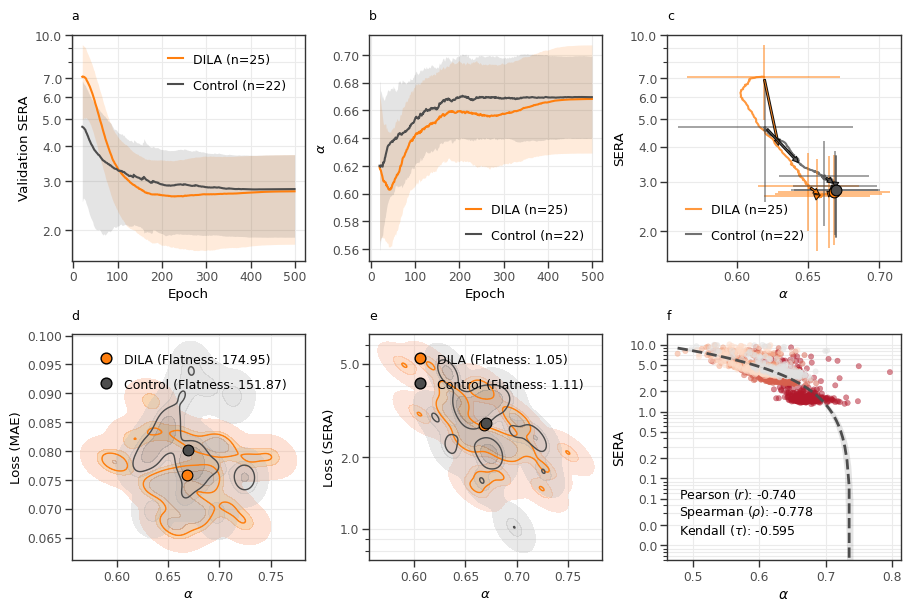

Saved unified analysis figure to figs/paper_final/log_kvrh_unified_analysis.jpg

Processing log_gvrh...


/tmp/ipykernel_1702707/3829267807.py:348: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


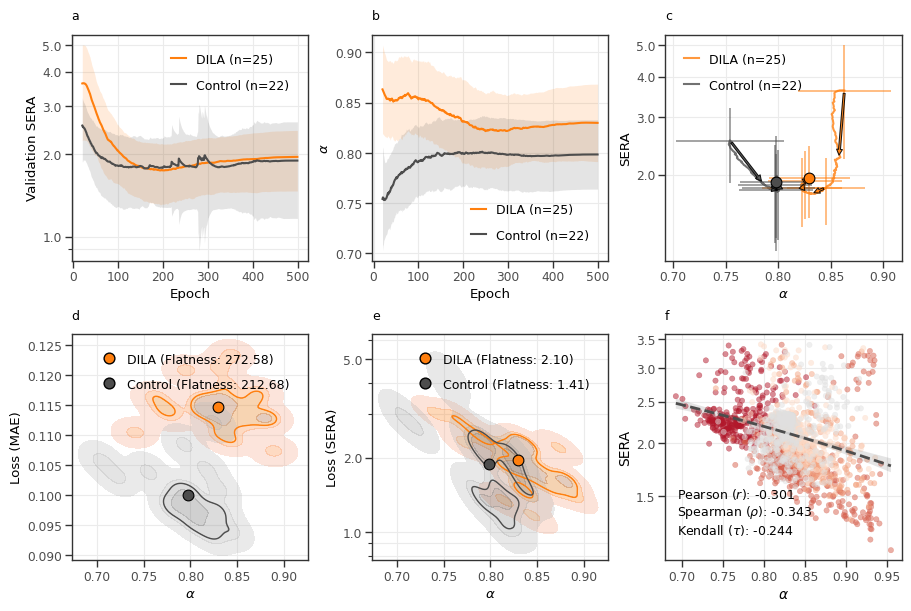

Saved unified analysis figure to figs/paper_final/log_gvrh_unified_analysis.jpg

Processing perovskites...


/tmp/ipykernel_1702707/3829267807.py:348: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


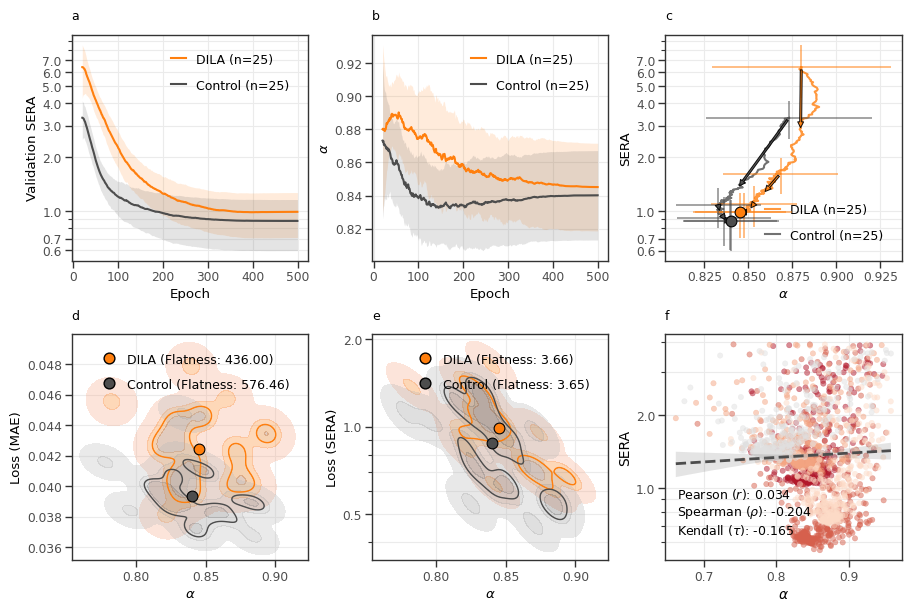

Saved unified analysis figure to figs/paper_final/perovskites_unified_analysis.jpg

Processing phonons...


/tmp/ipykernel_1702707/3829267807.py:348: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


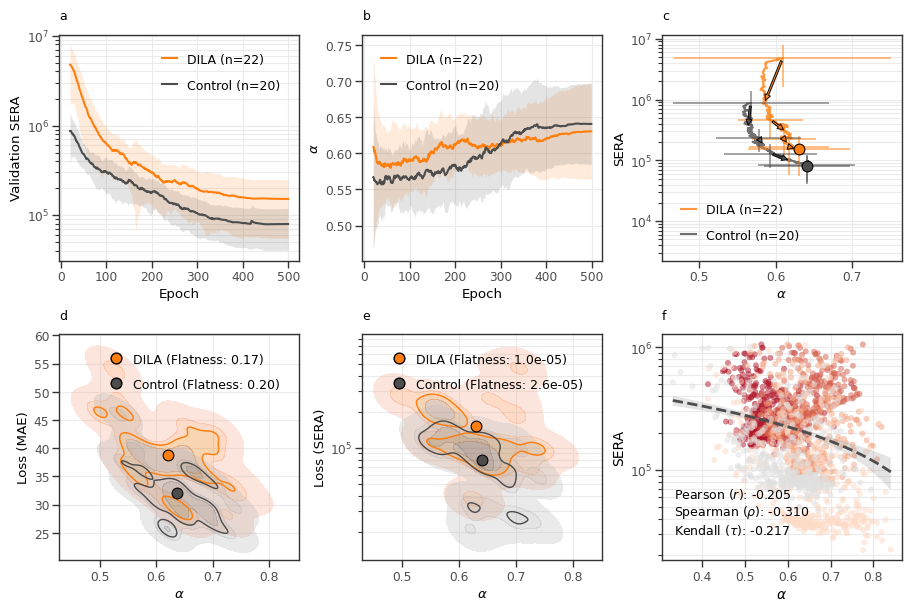

Saved unified analysis figure to figs/paper_final/phonons_unified_analysis.jpg

Saved combined LaTeX flatness table to figs/paper_final/combined_flatness_table.txt


In [12]:
standard_flatness_data = {}

print("\nProcessing log_kvrh...")
m_flat, s_flat = generate_analysis_figure(dataset='log_kvrh', primary_metric='sera')
standard_flatness_data['log_kvrh'] = {'mae': m_flat, 'sera': s_flat}

print("\nProcessing log_gvrh...")
m_flat, s_flat = generate_analysis_figure(dataset='log_gvrh', primary_metric='sera')
standard_flatness_data['log_gvrh'] = {'mae': m_flat, 'sera': s_flat}

print("\nProcessing perovskites...")
m_flat, s_flat = generate_analysis_figure(dataset='perovskites', primary_metric='sera', filter_runs=True)
standard_flatness_data['perovskites'] = {'mae': m_flat, 'sera': s_flat}

print("\nProcessing phonons...")
phonons_config = [
    {'label': 'DILA', 'color': '#ff7f0e', 'search_pattern': "experiments/final/phonons/smooth_dila/fold_*_run*_val_log*.csv"},
    {'label': 'Control', 'color': '#4d4d4d', 'search_pattern': "experiments/final/phonons/control/fold_*_run*_val_log*.csv"}
]
m_flat, s_flat = generate_analysis_figure(dataset='phonons', methods_config=phonons_config, primary_metric='sera', filter_runs=True)
standard_flatness_data['phonons'] = {'mae': m_flat, 'sera': s_flat}

# Generate the standard table
generate_latex_flatness_table(standard_flatness_data, "figs/paper_final/combined_flatness_table.txt")

### MatFold


Processing log_kvrh (Matfold)...


/tmp/ipykernel_1702707/3829267807.py:348: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


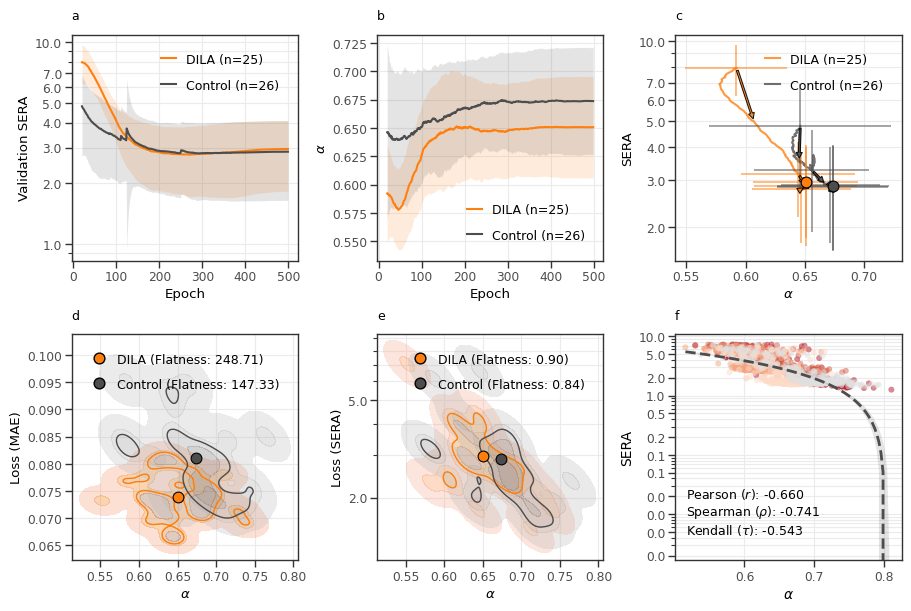

Saved unified analysis figure to figs/paper_final/log_kvrh_matfold_unified_analysis.jpg

Processing log_gvrh (Matfold)...


/tmp/ipykernel_1702707/3829267807.py:348: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


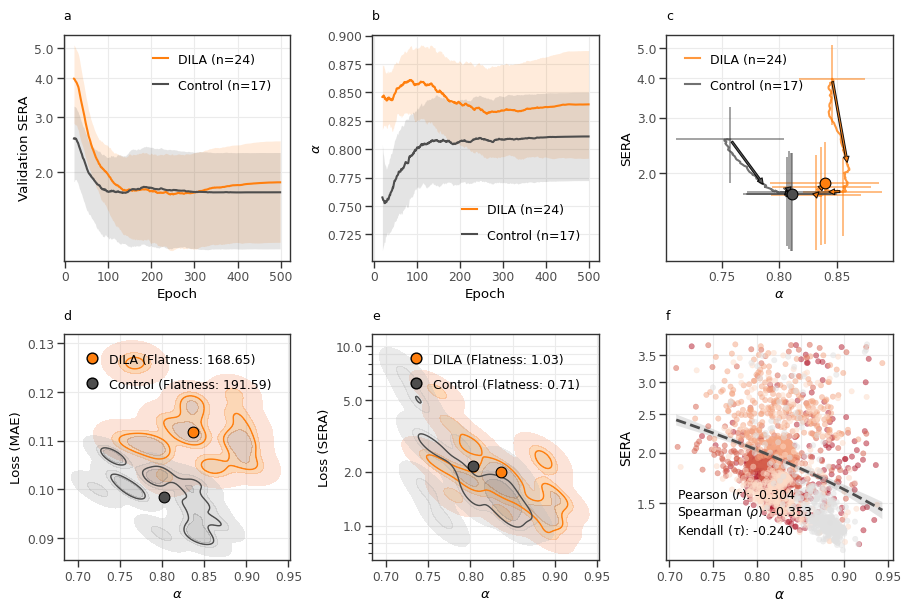

Saved unified analysis figure to figs/paper_final/log_gvrh_matfold_unified_analysis.jpg

Processing perovskites (Matfold)...


/tmp/ipykernel_1702707/3829267807.py:348: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


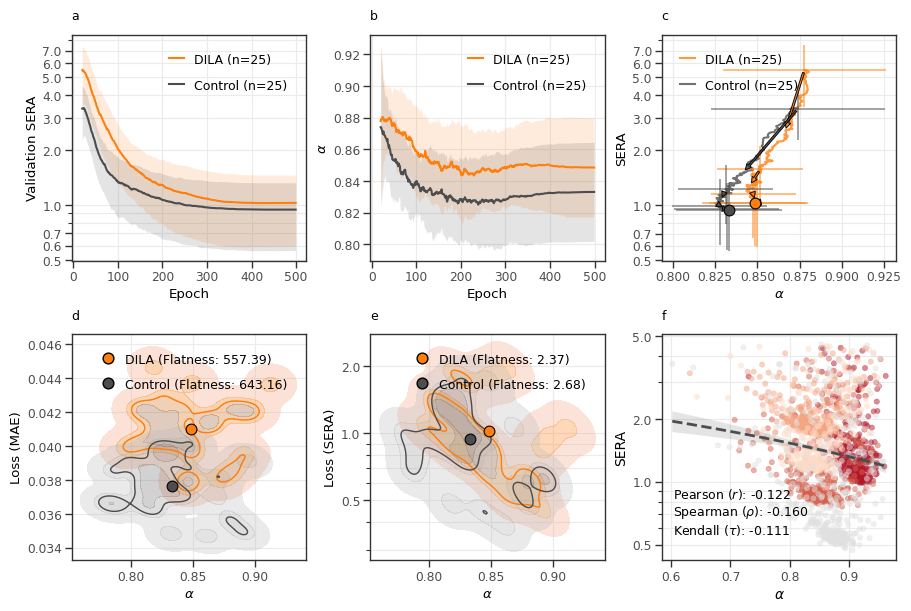

Saved unified analysis figure to figs/paper_final/perovskites_matfold_unified_analysis.jpg

Processing phonons (Matfold)...


/tmp/ipykernel_1702707/3829267807.py:348: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.scatterplot(


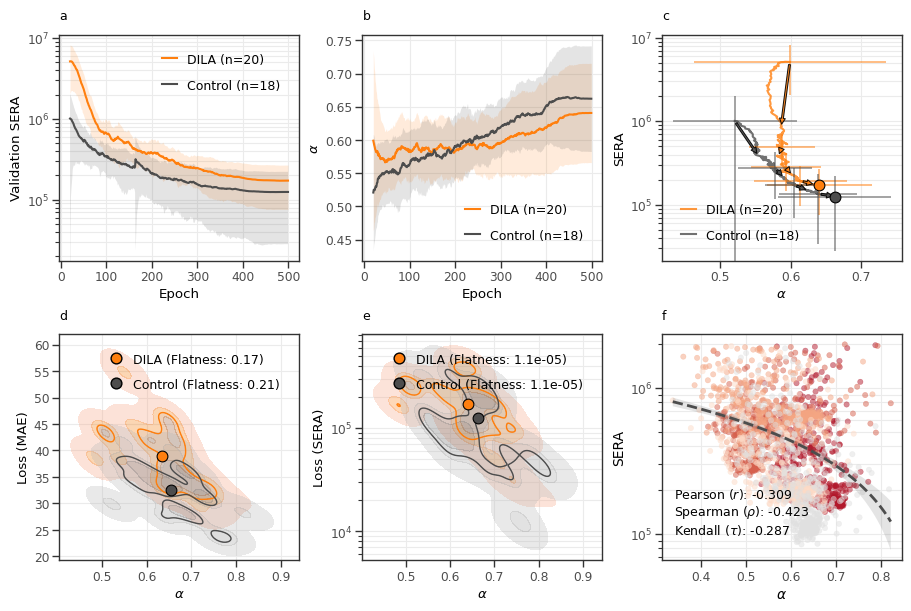

Saved unified analysis figure to figs/paper_final/phonons_matfold_unified_analysis.jpg

Saved combined LaTeX flatness table to figs/paper_final/matfold_combined_flatness_table.txt


In [13]:
matfold_flatness_data = {}

print("\nProcessing log_kvrh (Matfold)...")
m_flat, s_flat = generate_analysis_figure(
    dataset='log_kvrh', primary_metric='sera', result_dir='experiments/matfold',
    filename="figs/paper_final/log_kvrh_matfold_unified_analysis.jpg", filter_runs=True
)
matfold_flatness_data['log_kvrh'] = {'mae': m_flat, 'sera': s_flat}

print("\nProcessing log_gvrh (Matfold)...")
m_flat, s_flat = generate_analysis_figure(
    dataset='log_gvrh', primary_metric='sera', result_dir='experiments/matfold',
    filename="figs/paper_final/log_gvrh_matfold_unified_analysis.jpg", filter_runs=True,
    explode_ratio=50.0, conv_ratio=3.25
)
matfold_flatness_data['log_gvrh'] = {'mae': m_flat, 'sera': s_flat}

print("\nProcessing perovskites (Matfold)...")
m_flat, s_flat = generate_analysis_figure(
    dataset='perovskites', primary_metric='sera', result_dir='experiments/matfold',
    filename="figs/paper_final/perovskites_matfold_unified_analysis.jpg", filter_runs=True
)
matfold_flatness_data['perovskites'] = {'mae': m_flat, 'sera': s_flat}

print("\nProcessing phonons (Matfold)...")
m_flat, s_flat = generate_analysis_figure(
    dataset='phonons', primary_metric='sera', result_dir='experiments/matfold',
    filename="figs/paper_final/phonons_matfold_unified_analysis.jpg", filter_runs=True
)
matfold_flatness_data['phonons'] = {'mae': m_flat, 'sera': s_flat}

# Generate the matfold table (automatically inherits the bolding and Control/DILA sorting!)
generate_latex_flatness_table(matfold_flatness_data, "figs/paper_final/matfold_combined_flatness_table.txt")

## Fig 3. Model performance

**New data layer.** The deprecated `analyse_dataset`/`imba_analyser` stack is replaced
by the analysis API. The run index is screened once with the same trajectory-health
filter used in Fig 2; legacy npz runs (CV baselines, no val_logs) are recomputed from
raw arrays (package conventions, `SERA_T0 = 0.5`) and screened with the
prediction-level `filter_bad_runs`. `FoldAnalyser` exposes the old
`labels` / `all_preds` / `calculate_adaptive_discovery_metrics` / `_filter_bad_runs`
interface so the original Fig 4/5 code below runs unchanged.


In [14]:
METHODS_ORDERED = {"control": "Control", "dir": "DIR", "bsam": "BSAM",
                   "smooth_dila": "DILA"}


def _masked_final_stats(df, warmup_epochs=20, explode_ratio=100.0,
                        sera_explode_ratio=250.0):
    """Converged (last-5-epoch) validation MAE and R2 with exploded epochs
    masked out. An epoch is 'exploded' when its MAE (SERA) exceeds the run's
    own post-warmup median by explode_ratio (sera_explode_ratio) — genuine
    divergences overshoot these bounds by orders of magnitude."""
    post = df.iloc[warmup_epochs:]
    healthy = post
    if "mae" in healthy.columns:
        healthy = healthy[healthy["mae"] <= post["mae"].median() * explode_ratio]
    if "sera" in healthy.columns:
        healthy = healthy[healthy["sera"] <= post["sera"].median() * sera_explode_ratio]
    tail = healthy.iloc[-5:]
    r2 = tail["r2_score"].mean() if "r2_score" in tail.columns else np.nan
    return tail["mae"].mean(), r2


def filter_index_runs(index, warmup_epochs=20, conv_ratio=5.25, r2_floor=0.65):
    """Converged-health screen for prediction-level products (parity
    composites, metrics tables, screening analysers). Unlike the Fig-2
    trajectory filter (filter_outlier_runs), a transient mid-training
    explosion does NOT disqualify a run here: these products are computed
    from the best checkpoint, so a run that diverged mid-training but
    recovered is a valid sample (e.g. log_gvrh MatFold fold 1 Control, where
    all five runs spike at epochs 77-217 yet four converge to R2 0.81-0.86).
    Exploded epochs are masked before computing converged statistics; a run
    is dropped only if its converged quality is poor: final R2 < r2_floor,
    or final MAE above conv_ratio x the fold-best final MAE. Rows without a
    val_log are kept (screened later by filter_bad_runs)."""
    keep = []
    for (ds, meth, fold), g in index.groupby(["dataset", "method", "fold"]):
        stats, rows = [], []
        for i, row in g.iterrows():
            if row["val_log"] is None:
                keep.append(i)
                continue
            df = pd.read_csv(row["val_log"])
            if len(df) > warmup_epochs + 5:
                stats.append(_masked_final_stats(df, warmup_epochs))
                rows.append(i)
        finite = [m for m, _ in stats if np.isfinite(m)]
        if not finite:
            continue
        best = np.min(finite)
        for (mae, r2), i in zip(stats, rows):
            if not np.isfinite(mae) or mae > best * conv_ratio:
                continue
            if np.isfinite(r2) and r2 < r2_floor:
                continue
            keep.append(i)
    kept = index.loc[sorted(keep)].reset_index(drop=True)
    print(f"converged-health filter: kept {len(kept)}/{len(index)} runs")
    return kept


def load_npz_runs(pattern):
    """Legacy npz runs, metrics recomputed from raw arrays (SERA_T0 = 0.5),
    filtered per fold with the prediction-level screen."""
    import glob as _glob
    import re as _re
    by_fold = {}
    for path in sorted(_glob.glob(pattern)):
        raw = PredictionSet.load(path)
        name = os.path.basename(path).replace("_ml_pred.npz", "")
        ps = PredictionSet(raw.targets, raw.preds, relevances=raw.relevances,
                           densities=raw.densities, name=name)
        m = _re.search(r"fold_(\d+)", name)
        by_fold.setdefault(m.group(1) if m else "0", []).append(ps)
    return [ps for runs in by_fold.values() for ps in filter_bad_runs(runs)]


def collect_filtered(base, merge_npz=False):
    """{dataset: {method: [PredictionSet]}} from the filtered run index."""
    index = filter_index_runs(discover_runs(base))
    preds = load_predictions(index) if not index.empty else {}
    if merge_npz:
        for dataset in ("log_kvrh", "log_gvrh", "perovskites", "phonons"):
            for method in METHODS_ORDERED:
                runs = load_npz_runs(os.path.join(
                    base, dataset, method, "fold_*_run*_ml_pred.npz"))
                if runs:
                    preds.setdefault(dataset, {})[method] = runs
    return index, preds


class FoldAnalyser:
    """Adapter exposing the old imba_analyser interface over analysis objects."""

    def __init__(self, labels, all_preds):
        self.labels = labels        # e.g. ['Control', 'DIR', 'BSAM', 'DILA']
        self.all_preds = all_preds  # per method: list[PredictionSet] for one fold

    def _filter_bad_runs(self, runs):
        return filter_bad_runs(runs)

    def calculate_adaptive_discovery_metrics(self, pred_group, budget_ratio=1.0,
                                             rel_threshold=0.5,
                                             discover_mode="auto"):
        try:
            return discovery_metrics(pred_group, rel_threshold=rel_threshold,
                                     budget_ratio=budget_ratio,
                                     discover_mode=discover_mode)
        except Exception as e:
            return {"Error": str(e)}


def build_analysers(preds_by_method, folds=range(5)):
    analysers = []
    for fold in folds:
        labels, all_preds = [], []
        for method, label in METHODS_ORDERED.items():
            runs = [p for p in preds_by_method.get(method, [])
                    if p.name and p.name.startswith(f"fold_{fold}_")]
            if runs:
                labels.append(label)
                all_preds.append(runs)
        analysers.append(FoldAnalyser(labels, all_preds))
    return analysers


In [15]:
index_cv, preds_cv = collect_filtered("experiments/final", merge_npz=True)
index_mf, preds_mf = collect_filtered("experiments/matfold")

datasets = ["log_kvrh", "log_gvrh", "perovskites", "phonons"]
math_names = [r"log($K_{\mathrm{{vrh}}}$)", r"log($G_{\mathrm{{vrh}}}$)",
              r"$E_{\mathrm{{F}}}$ [eV cell$^{-1}$]",
              r"$\nu _{\mathrm{{last}}}$ [cm$^{-1}$]"]

for dataset in datasets:
    globals()[f"{dataset}_analysers"] = build_analysers(preds_cv.get(dataset, {}))
    globals()[f"matfold_{dataset}_analysers"] = build_analysers(preds_mf.get(dataset, {}))
print("analysers built for", datasets)


converged-health filter: kept 100/100 runs
converged-health filter: kept 401/405 runs
analysers built for ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']


#### CV

Per-fold aggregated composites (parity + SER + binned MAE), one figure per fold, via the packaged `summary_plot` (the port of the original layout).

In [16]:
def fold_groups(preds_by_method, fold):
    groups = {}
    for method, label in METHODS_ORDERED.items():
        runs = [p for p in preds_by_method.get(method, [])
                if p.name and p.name.startswith(f"fold_{fold}_")]
        if runs:
            groups[label] = runs
    return groups


for prefix, preds in (("", preds_cv), ("matfold_", preds_mf)):
    for dataset, math_name in zip(datasets, math_names):
        for fold in range(5):
            groups = fold_groups(preds.get(dataset, {}), fold)
            if not groups:
                continue
            fig = summary_plot(groups, target_name=math_name)
            fig.savefig(f"figs/paper_final/{prefix}{dataset}_fold{fold}_aggregated.jpg",
                        dpi=600, bbox_inches="tight")
            plt.close(fig)
        print(f"{prefix or 'cv_'}{dataset}: per-fold composites saved")


cv_log_kvrh: per-fold composites saved
cv_log_gvrh: per-fold composites saved
cv_perovskites: per-fold composites saved
cv_phonons: per-fold composites saved
matfold_log_kvrh: per-fold composites saved
matfold_log_gvrh: per-fold composites saved
matfold_perovskites: per-fold composites saved
matfold_phonons: per-fold composites saved


Comprehensive metric tables — ddof = 1 sample statistics with significant-figure formatting and bold-best LaTeX (replaces the old ddof = 0 table generator; Referees 2, 3).

In [17]:
for name, preds in (("cv", preds_cv), ("matfold", preds_mf)):
    agg = aggregate(metrics_table(preds))
    ft = formatted_table(agg)
    ft.to_csv(f"figs/paper_final/comprehensive_metrics_{name}.csv", index=False)
    with open(f"figs/paper_final/comprehensive_metrics_table_{name}.txt", "w") as f:
        for metric in ("mae", "sera", "alpha"):
            if f"{metric}_mean" in agg.columns and agg["method"].nunique() > 1:
                f.write(to_latex_bold_best(agg, metric) + "\n\n")
ft


,dataset,method,mae,r2,sera,alpha,tail_mae,head_mae
0,log_gvrh,bsam,0.120 ± 0.006,0.796 ± 0.016,6 ± 3,0.82 ± 0.03,0.21 ± 0.02,0.115 ± 0.006
1,log_gvrh,control,0.122 ± 0.007,0.79 ± 0.02,6 ± 3,0.82 ± 0.03,0.20 ± 0.03,0.117 ± 0.007
2,log_gvrh,dir,0.122 ± 0.007,0.79 ± 0.02,5 ± 3,0.82 ± 0.02,0.21 ± 0.02,0.118 ± 0.007
3,log_gvrh,smooth_dila,0.126 ± 0.007,0.77 ± 0.02,6 ± 4,0.83 ± 0.03,0.21 ± 0.02,0.122 ± 0.007
4,log_kvrh,bsam,0.092 ± 0.005,0.837 ± 0.019,8 ± 4,0.67 ± 0.03,0.26 ± 0.03,0.084 ± 0.005
5,log_kvrh,control,0.093 ± 0.005,0.831 ± 0.017,9 ± 5,0.66 ± 0.02,0.26 ± 0.04,0.085 ± 0.004
6,log_kvrh,dir,0.093 ± 0.005,0.834 ± 0.017,8 ± 4,0.67 ± 0.03,0.25 ± 0.04,0.085 ± 0.005
7,log_kvrh,smooth_dila,0.086 ± 0.004,0.843 ± 0.015,8 ± 4,0.66 ± 0.03,0.26 ± 0.03,0.078 ± 0.003
8,perovskites,bsam,0.10 ± 0.02,0.94 ± 0.07,8 ± 8,0.80 ± 0.10,0.13 ± 0.04,0.09 ± 0.02
9,perovskites,control,0.090 ± 0.016,0.96 ± 0.05,8 ± 8,0.79 ± 0.11,0.13 ± 0.04,0.085 ± 0.019


## Fig 4. Out of distribution discovery metrics

*`calc_imba_metrics` and `plot_discovery_analysis` below are the original code, unchanged — they now consume the `FoldAnalyser` adapters, whose `calculate_adaptive_discovery_metrics` delegates to the packaged `discovery_metrics`.*

In [18]:
def calc_imba_metrics(imba_analysers, rel_thresholds = np.linspace(0.5, 0.9, num = 9),
                      budget_ratios= np.linspace(0.5, 3, num = 11), discover_mode = 'high'):
    all_results = []
    for fold, imba_analyser in enumerate(imba_analysers):
        for rel_threshold in rel_thresholds:
            for budget_ratio in budget_ratios:
                for i, method in enumerate(imba_analyser.labels):
                    results = imba_analyser.calculate_adaptive_discovery_metrics(
                        imba_analyser.all_preds[i], budget_ratio=budget_ratio, rel_threshold = rel_threshold, discover_mode = discover_mode
                    )
                    
                    # --- THE FIX: Skip this configuration if the tail is empty ---
                    if 'Error' in results:
                        continue 
                    # -------------------------------------------------------------

                    # Filter the dictionary for the keys you need
                    filtered_results = {key: results[key] for key in [
                        'Discovery Mode', 'Tail Size (GT)', 'Extrap. Precision',
                        'Tail Recall', 'Tail MAE',
                        'Breakdown'
                    ]}
                    filtered_results.update({
                        'Method': method,
                        'Rel Threshold': rel_threshold,
                        'Budget Ratio': budget_ratio,
                        'Fold': fold
                    })
            
                    # Collect the dictionary in a list
                    all_results.append(filtered_results)

    # Create the final DataFrame from the list of dictionaries
    df = pd.DataFrame(all_results)
    return df

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_discovery_analysis(df, axes=None, rel_threshold=0.8, save_path=None):
    """
    Generates a comprehensive Discovery Performance analysis figure.
    Plots Efficiency (Precision), Completeness (Recall), and Error (MAE).
    """
    # 1. Filter Data for the specific difficulty level
    subset = df[df['Rel Threshold'] == rel_threshold].copy()
    
    if subset.empty:
        print(f"No data found for Rel Threshold = {rel_threshold}")
        return

    if axes is None:
        fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.8), constrained_layout=True)
    
    # 3. Define EXACT formatting mapped from compare_mae_wb & analyse_method_sensitivity
    models = sorted(subset['Method'].unique())
    e_colors = ['#4d4d4d', '#2166ac', '#b2182b', '#35978f', '#ff7f0e'] 
    f_colors = ['#e0e0e0', '#d1e5f0', '#fff5eb', '#c7eae5', '#ffbb78']
    markers = ['s', 'o', '^', 'v', 'D']
    
    # Helper for consistent lineplots
    def plot_metric(ax, metric_col, ylabel, show_legend=False):
        # We loop through methods to explicitly control marker face/edge colors
        for i, method in enumerate(['Control', 'DIR', 'BSAM', 'DILA']):
            c_idx = i % len(e_colors)
            
            sns.lineplot(
                data=subset[subset['Method'] == method], 
                x='Budget Ratio', 
                y=metric_col,
                ax=ax, 
                color=e_colors[c_idx],       # Line and CI Band color
                linewidth=1.5, 
                errorbar=('ci', 95),         # 95% Confidence Interval
                err_style='band', 
                label=method if show_legend else None,
                # --- EXACT MARKER FORMATTING ---
                marker=markers[c_idx],
                markersize=7,
                markeredgecolor=e_colors[c_idx],
                markerfacecolor=f_colors[c_idx]
            )
            
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xlabel('Budget Ratio (x Tail Size)', fontsize=10)
        ax.axvline(1.0, color='#555555', linestyle='--', alpha=0.6)
        
        if show_legend:
            ax.legend(fontsize=8, loc='best')

    # --- Panel A: Efficiency (Precision) ---
    plot_metric(
        axes[0], 'Extrap. Precision', 
        'Success Rate (Precision)'
    )
    
    # --- Panel B: Completeness (Recall) ---
    plot_metric(
        axes[1], 'Tail Recall', 
        'Fraction Found (Recall)',
        show_legend=True # Show legend on middle plot
    )
    
    # --- Panel C: Quality (Tail MAE) ---
    plot_metric(
        axes[2], 'Tail MAE', 
        'Tail MAE (eV)'
    )
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
        
    if axes is None:
        plt.show()

#### CV

In [19]:
phonons_metrics = calc_imba_metrics(phonons_analysers, discover_mode = 'high')
phonons_metrics.to_csv('results/phonons_discov_metrics.csv', index = None)
log_kvrh_metrics = calc_imba_metrics(log_kvrh_analysers, discover_mode = 'high')
log_kvrh_metrics.to_csv('results/log_kvrh_discov_metrics.csv', index = None)
log_gvrh_metrics = calc_imba_metrics(log_gvrh_analysers, discover_mode = 'high')
log_gvrh_metrics.to_csv('results/log_gvrh_discov_metrics.csv', index = None)
perovskites_metrics = calc_imba_metrics(perovskites_analysers, discover_mode = 'low')
perovskites_metrics.to_csv('results/perovskites_discov_metrics.csv', index = None)

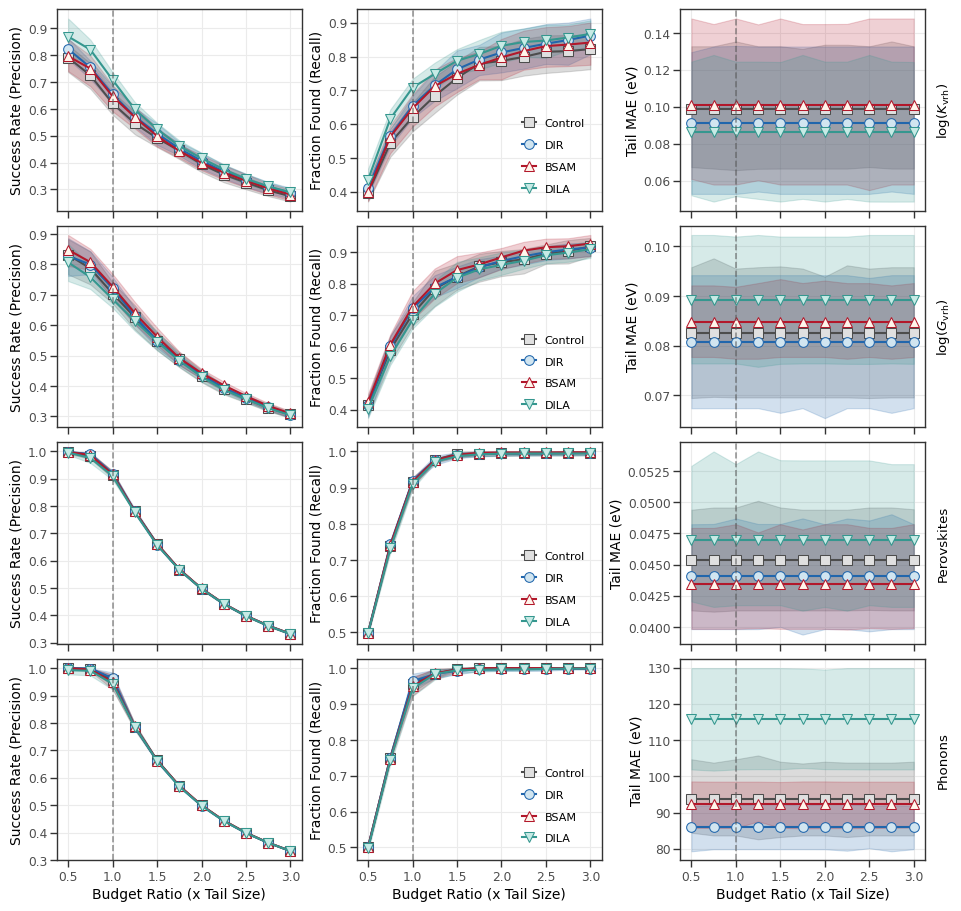

In [20]:
log_kvrh_results=pd.read_csv("results/log_kvrh_discov_metrics.csv")
log_gvrh_results=pd.read_csv("results/log_gvrh_discov_metrics.csv")
phonons_results = pd.read_csv("results/phonons_discov_metrics.csv")
perovskites_results=pd.read_csv("results/perovskites_discov_metrics.csv")

fig, (axes1, axes2, axes3, axes4)=plt.subplots(4,3, figsize=(9.5, 9), sharex='col', layout = 'compressed')
plot_discovery_analysis(log_kvrh_results, axes=axes1, rel_threshold=0.8)
plot_discovery_analysis(log_gvrh_results, axes=axes2, rel_threshold=0.8)
plot_discovery_analysis(perovskites_results, axes=axes3, rel_threshold=0.8)
plot_discovery_analysis(phonons_results, axes=axes4, rel_threshold=0.8)

datasets=[r"log($K_{\mathrm{vrh}}$)", r"log($G_{\mathrm{vrh}}$)", 'Perovskites', 'Phonons']
for i, axes in enumerate((axes1, axes2, axes3, axes4)):
    axes[-1].text(1.075, 0.5, datasets[i], va='center', ha='center', rotation=90, transform=axes[-1].transAxes)

plt.savefig('figs/paper_final/discov_performance.jpg', dpi=600)

#### MatFold

In [21]:
phonons_metrics = calc_imba_metrics(matfold_phonons_analysers, discover_mode = 'high')
phonons_metrics.to_csv('results/phonons_matfold_discov_metrics.csv', index = None)
log_kvrh_metrics = calc_imba_metrics(matfold_log_kvrh_analysers, discover_mode = 'high')
log_kvrh_metrics.to_csv('results/log_kvrh_matfold_discov_metrics.csv', index = None)
log_gvrh_metrics = calc_imba_metrics(matfold_log_gvrh_analysers, discover_mode = 'high')
log_gvrh_metrics.to_csv('results/log_gvrh_matfold_discov_metrics.csv', index = None)
perovskites_metrics = calc_imba_metrics(matfold_perovskites_analysers, discover_mode = 'low')
perovskites_metrics.to_csv('results/perovskites_matfold_discov_metrics.csv', index = None)

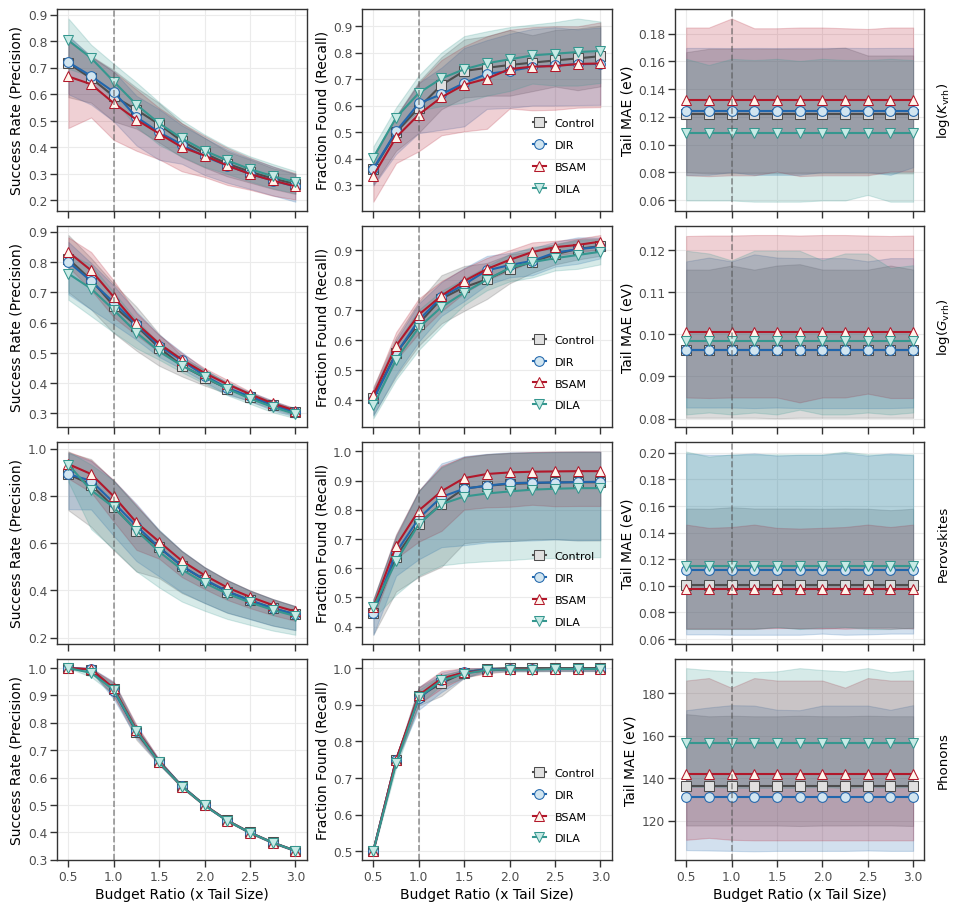

In [22]:
log_kvrh_results=pd.read_csv("results/log_kvrh_matfold_discov_metrics.csv")
log_gvrh_results=pd.read_csv("results/log_gvrh_matfold_discov_metrics.csv")
phonons_results = pd.read_csv("results/phonons_matfold_discov_metrics.csv")
perovskites_results=pd.read_csv("results/perovskites_matfold_discov_metrics.csv")

fig, (axes1, axes2, axes3, axes4)=plt.subplots(4,3, figsize=(9.5, 9), sharex='col', layout = 'compressed')
plot_discovery_analysis(log_kvrh_results, axes=axes1, rel_threshold=0.8)
plot_discovery_analysis(log_gvrh_results, axes=axes2, rel_threshold=0.8)
plot_discovery_analysis(perovskites_results, axes=axes3, rel_threshold=0.8)
plot_discovery_analysis(phonons_results, axes=axes4, rel_threshold=0.8)

datasets=[r"log($K_{\mathrm{vrh}}$)", r"log($G_{\mathrm{vrh}}$)", 'Perovskites', 'Phonons']
for i, axes in enumerate((axes1, axes2, axes3, axes4)):
    axes[-1].text(1.075, 0.5, datasets[i], va='center', ha='center', rotation=90, transform=axes[-1].transAxes)

plt.savefig('figs/paper_final/matfold_discov_performance.jpg', dpi=600)

## Fig 5. SERA & alpha performance of Matbench datasets

*Original code unchanged; run objects are `PredictionSet`s and `_filter_bad_runs` delegates to the packaged prediction-level screen.*

In [23]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import r2_score
from MatImba.utils.losses import calc_sera

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Knowledge Base: Dataset Indices ---
DATASET_META = {
    'log_kvrh':    {'h': 0.516, 'w1': 0.207},
    'log_gvrh':    {'h': 0.498, 'w1': 0.153},
    'phonons':     {'h': 0.631, 'w1': 0.354},
    'perovskites': {'h': 0.521, 'w1': 0.186}
}

# --- MINIMAL CHANGE: Compute PCA for h and w1 ---
meta_df = pd.DataFrame.from_dict(DATASET_META, orient='index')
scaler = StandardScaler()
coords = PCA(n_components=2).fit_transform(scaler.fit_transform(meta_df[['h', 'w1']]))

for i, ds_name in enumerate(meta_df.index):
    DATASET_META[ds_name]['PC1'] = coords[i, 0]
    DATASET_META[ds_name]['PC2'] = coords[i, 1]

import numpy as np
import pandas as pd
import torch
from MatImba.utils.losses import calc_sera, calc_alpha

def extract_robust_metrics(dataset, analysers, sera_t_threshold=0.8):
    """
    Extracts SERA and Alpha metrics directly from the list of imba_analyser 
    objects returned by analyse_dataset, utilizing their internal _filter_bad_runs.
    """
    # Safety: ensure it's a list even if a single analyser object is passed
    if not isinstance(analysers, list):
        analysers = [analysers]
        
    metrics_dict = {}
    if not analysers:
        return pd.DataFrame()

    # The labels (methods) are natively stored in the analyser object
    methods = analysers[0].labels

    for i, method in enumerate(methods):
        valid_folds = []
        
        # Each analyser in the list represents one fold
        for fold, analyser in enumerate(analysers):
            if i >= len(analyser.all_preds): continue
            
            # --- MINIMAL CHANGE: Use the analyser's native filter in memory ---
            raw_runs = analyser.all_preds[i]
            valid_runs = analyser._filter_bad_runs(raw_runs)
            
            if not valid_runs: continue
            
            # Extract arrays directly from the valid run objects
            labels = np.concatenate([np.ravel(p.targets) for p in valid_runs])
            preds = np.concatenate([np.ravel(p.preds) for p in valid_runs])
            maes = np.abs(labels - preds)
            
            # 1. Compute SERA
            if hasattr(valid_runs[0], 'relevances') and valid_runs[0].relevances is not None:
                relevances = np.concatenate([np.ravel(p.relevances) for p in valid_runs])
                sera_val = calc_sera(labels, preds, relevances, t=sera_t_threshold)
                sera_val = float(sera_val.item()) if hasattr(sera_val, 'item') else float(sera_val)
            else:
                sera_val = np.nan
                
            # 2. Compute Alpha
            if hasattr(valid_runs[0], 'densities') and valid_runs[0].densities is not None:
                densities = np.concatenate([np.ravel(p.densities) for p in valid_runs])
                if len(densities) > 3:
                    alpha_val = float(calc_alpha(
                        torch.as_tensor(labels, dtype=torch.float32),
                        torch.as_tensor(preds, dtype=torch.float32),
                        torch.as_tensor(densities, dtype=torch.float32),
                    ).item())
                else:
                    alpha_val = np.nan
            else:
                alpha_val = np.nan
                
            valid_folds.append({
                'fold': fold,
                'test_sera': sera_val,
                'test_awareness': alpha_val
            })
            
        if valid_folds:
            metrics_dict[method] = pd.DataFrame(valid_folds)

    # --- Identify the Control baseline dynamically ---
    ctrl_key = next((k for k in metrics_dict.keys() if k.lower() == 'control'), None)
    
    if not ctrl_key:
        print(f"Warning: No valid control data found for {dataset}")
        return pd.DataFrame()

    # Build per-fold Control lookups for paired comparison.
    # Using ctrl_mean as the reference introduced a structural positive bias: folds where
    # SERA is naturally low (easy folds) produced inflated Δ% even when the method was
    # no better than Control on that specific fold.  Paired comparison eliminates
    # between-fold variance and gives an unbiased per-fold effect estimate.
    ctrl_df = metrics_dict[ctrl_key].set_index('fold')
    ctrl_sera_by_fold  = ctrl_df['test_sera'].to_dict()
    ctrl_alpha_by_fold = ctrl_df['test_awareness'].to_dict()

    rows = []
    for method, method_df in metrics_dict.items():
        if method == ctrl_key: continue
        
        # Clean up method name for plotting
        prefix = 'DILA' if 'dila' in method.lower() else method.upper()
        
        for _, fold_row in method_df.iterrows():
            fold     = fold_row['fold']
            sera_val = fold_row['test_sera']
            alpha_val = fold_row['test_awareness']
            
            # Paired per-fold delta vs the same fold's Control
            ctrl_sera_fold  = ctrl_sera_by_fold.get(fold, np.nan)
            ctrl_alpha_fold = ctrl_alpha_by_fold.get(fold, np.nan)

            if pd.notnull(ctrl_sera_fold) and ctrl_sera_fold > 0:
                sera_delta = ((ctrl_sera_fold - sera_val) / ctrl_sera_fold) * 100
            else:
                sera_delta = np.nan

            alpha_gain = (alpha_val - ctrl_alpha_fold) if pd.notnull(ctrl_alpha_fold) else np.nan
            
            rows.append({
                'dataset': dataset,
                'method': prefix,
                'fold': fold,
                'sera_delta': float(sera_delta) if pd.notnull(sera_delta) else np.nan,
                'alpha_gain': float(alpha_gain) if pd.notnull(alpha_gain) else np.nan
            })
            
    return pd.DataFrame(rows)

def aggregate_datasets(results_map, meta_data):
    """Aggregates all dataset dataframes into one master long-format dataframe."""
    dfs = []
    for ds_name, df in results_map.items():
        if df.empty: continue
        df_copy = df.copy()
        
        if ds_name in meta_data:
            df_copy['h_index'] = meta_data[ds_name]['h']
            df_copy['w1_dist'] = meta_data[ds_name]['w1']
            # --- MINIMAL CHANGE: Add PC columns ---
            df_copy['PC1'] = meta_data[ds_name]['PC1']
            df_copy['PC2'] = meta_data[ds_name]['PC2']
            
        dfs.append(df_copy)
    return pd.concat(dfs, ignore_index=True)

# --- ANALYSIS: Styled CI Plotter with Top Spine Ticks ---
def analyse_method_sensitivity(df, ax, x_metric='h_index', performance='sera', 
                               is_top_row=False, estimator='median', error_type='sem'):
    """
    Plots performance metric against dataset difficulty.
    Upgraded to use statistically robust estimators (Median + SEM) to prevent 
    heavy-tailed metrics like SERA from exploding the error bars.
    """

    y_metric = 'sera_delta' if performance == 'sera' else 'alpha_gain'
    
    # Exact formatting mapped from compare_mae_wb
    e_colors = ['#2166ac', '#b2182b', '#35978f'] 
    f_colors = ['#d1e5f0', '#fff5eb', '#c7eae5']
    markers = ['o', '^', 'v']
    method_names = ['DIR', 'BSAM', 'DILA']
    
    x_min, x_max = df[x_metric].min(), df[x_metric].max()
    offset_step = (x_max - x_min) * 0.015 if x_max > x_min else 0.01

    for idx, name in enumerate(method_names):
        method_df = df[df['method'] == name]
        if method_df.empty: continue
        
        # --- ROBUST STATISTICAL AGGREGATION ---
        # Calculate the central tendency (Mean or Median)
        if estimator == 'median':
            grouped_center = method_df.groupby(x_metric)[y_metric].median().reset_index(name='center')
        else:
            grouped_center = method_df.groupby(x_metric)[y_metric].mean().reset_index(name='center')
            
        # Calculate the dispersion (Std, Count, and SEM/CI)
        grouped_stats = method_df.groupby(x_metric)[y_metric].agg(['count', 'std']).reset_index()
        grouped = pd.merge(grouped_center, grouped_stats, on=x_metric)
        
        # Determine Error Bar Size
        if error_type == 'sem':
            # Standard Error of the Mean (Tight, robust bounds)
            grouped['error'] = grouped['std'] / np.sqrt(grouped['count'])
        elif error_type == 'ci95':
            # 95% Confidence Interval (Large, heavily penalized by small N)
            grouped['error'] = grouped.apply(
                lambda row: stats.t.ppf(0.975, df=row['count']-1) * (row['std'] / np.sqrt(row['count'])) 
                if row['count'] > 1 and pd.notnull(row['std']) else 0, 
                axis=1
            )
        elif error_type == 'iqr' and estimator == 'median':
             # Interquartile Range (If you want purely non-parametric bounds)
             q1 = method_df.groupby(x_metric)[y_metric].quantile(0.25).reset_index(name='q1')
             q3 = method_df.groupby(x_metric)[y_metric].quantile(0.75).reset_index(name='q3')
             grouped = pd.merge(grouped, q1, on=x_metric)
             grouped = pd.merge(grouped, q3, on=x_metric)
             # Error format for matplotlib: shape(2, N) -> [lower_errors, upper_errors]
             grouped['err_lower'] = grouped['center'] - grouped['q1']
             grouped['err_upper'] = grouped['q3'] - grouped['center']
        
        # --- PLOTTING ---
        # Slight jitter to prevent exact overlap
        x_vals = grouped[x_metric] + ((idx - 1) * offset_step)
        
        if error_type == 'iqr' and estimator == 'median':
            yerr = [grouped['err_lower'], grouped['err_upper']]
        else:
            yerr = grouped['error']
        
        # Plot with exact formatting from compare_mae_wb
        ax.errorbar(
            x_vals, grouped['center'], yerr=yerr,
            c=e_colors[idx], marker=markers[idx], ms=7,
            markerfacecolor=f_colors[idx], alpha=0.8, label=name,
            linestyle='none', capsize=0, elinewidth=1.5
        )

    ax.axhline(0, color='black', lw=1.5, alpha=0.4, linestyle=':')
    
    # --- MINIMAL CHANGE: Add PC1/PC2 labels ---
    if x_metric == 'h_index': x_label = "Distribution Imbalance ($h$)"
    elif x_metric == 'w1_dist': x_label = r"Wasserstein Distance ($W_1$)"
    elif x_metric == 'PC1': x_label = f"PC1: ({pca.explained_variance_ratio_[0]:.1%} var) Statistical\n Imbalance Magnitude"
    elif x_metric == 'PC2': x_label = f"PC2: ({pca.explained_variance_ratio_[1]:.1%} var)\n Geometric Transport Cost"
    else: x_label = x_metric
    
    ax.set_xlabel(x_label, fontsize=10)
    
    if not is_top_row:
        ax.legend(loc='best', fontsize=8)

    # --- TOP SPINE TEXT TICKS ---
    if is_top_row:
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        
        unique_ds = df[[x_metric, 'dataset']].drop_duplicates().sort_values(by=x_metric)
        
        def format_ds_name(name):
            if name == 'log_kvrh': return r"$\log(K_{\mathrm{vrh}})$"
            if name == 'log_gvrh': return r"$\log(G_{\mathrm{vrh}})$"
            if name == 'phonons': return 'Phonons'
            if name == 'perovskites': return 'Perovskites'
            return name
            
        ax_top.set_xticks(unique_ds[x_metric])
        ax_top.set_xticklabels([format_ds_name(ds) for ds in unique_ds['dataset']], fontsize=9, rotation=90)
        ax_top.grid(False)
        # ax_top.tick_params(axis='x', direction='in', pad=-50, zorder=10)

In [24]:
datasets = ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']
methods_to_eval = ['control', 'dir', 'bsam', 'smooth_dila'] 
print("Extracting Robust Metrics (Computing 95% CI for all runs)...")

dataset_results_map = {}
for dataset in datasets:
    dataset_results_map[dataset] = extract_robust_metrics(
        dataset=dataset, 
        analysers=globals()[f"{dataset}_analysers"], 
    )

master_df = aggregate_datasets(dataset_results_map, meta_data=DATASET_META)

matfold_results_map = {}
for dataset in datasets:
    matfold_results_map[dataset] = extract_robust_metrics(
        dataset=dataset, 
        analysers=globals()[f"matfold_{dataset}_analysers"],
    )
matfold_df = aggregate_datasets(matfold_results_map, meta_data=DATASET_META)

Extracting Robust Metrics (Computing 95% CI for all runs)...



--- Plotting Analysis Grid ---


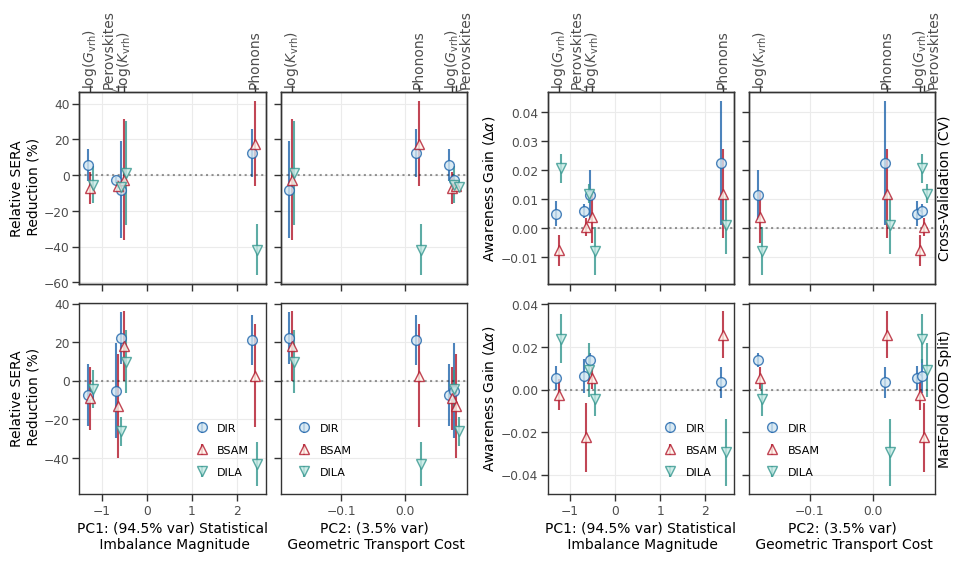

In [25]:
import matplotlib.transforms as transforms
import matplotlib.pyplot as plt

print("\n--- Plotting Analysis Grid ---")
fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(9.5, 5.5), layout='constrained')

# ROW 1: SERA Reduction (%) [Top row -> is_top_row=True]
analyse_method_sensitivity(master_df, ax1, x_metric='PC1', performance='sera', is_top_row=True)
analyse_method_sensitivity(master_df, ax2, x_metric='PC2', performance='sera', is_top_row=True)
analyse_method_sensitivity(master_df, ax3, x_metric='PC1', performance='alpha', is_top_row=True)
analyse_method_sensitivity(master_df, ax4, x_metric='PC2', performance='alpha', is_top_row=True)

ax1.set_ylabel("Relative SERA\n Reduction (%)", fontsize=10)
ax2.set_ylabel("")
ax4.set_ylabel("")

analyse_method_sensitivity(matfold_df, ax5, x_metric='PC1', performance='sera', is_top_row=False)
analyse_method_sensitivity(matfold_df, ax6, x_metric='PC2', performance='sera', is_top_row=False)
analyse_method_sensitivity(matfold_df, ax7, x_metric='PC1', performance='alpha', is_top_row=False)
analyse_method_sensitivity(matfold_df, ax8, x_metric='PC2', performance='alpha', is_top_row=False)

ax5.set_ylabel("Relative SERA\n Reduction (%)", fontsize=10)
ax7.set_ylabel(r"Awareness Gain ($\Delta \alpha$)", fontsize=10) 

# Link axes for visual alignment
ax2.sharey(ax1)
ax4.sharey(ax3)
ax1.sharex(ax5)
ax2.sharex(ax6)
ax6.sharey(ax5)
ax8.sharey(ax7)
ax3.sharex(ax7)
ax4.sharex(ax8)

# Label outer disables tick labels on inner axes.
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]:
    ax.label_outer()

for ax in [ax3, ax7]:
    ax.tick_params(labelleft=True)
    ax.yaxis.label.set_visible(True)
    ax.set_ylabel(r"Awareness Gain ($\Delta \alpha$)", fontsize=10)


# --- THE SIMPLE TEXT REPLACEMENT ---
# 1. Force the canvas to draw so the coordinates exist in memory
fig.canvas.draw() 

# Keywords to identify the top labels instead of numeric bottom ticks
dataset_keywords = ['vrh', 'Perov', 'perov', 'Phonon', 'phonon']

# 2. Iterate through every axis (including hidden twin axes)
for ax in fig.axes:
    for label in ax.get_xticklabels():
        text_str = label.get_text()
        
        # Check if the label is one of our dataset names
        if any(keyword in text_str for keyword in dataset_keywords):
            x_val = label.get_position()[0]
            
            # Turn off the rigid Matplotlib tick label completely
            label.set_visible(False)
            
            # Setup the transform for custom text (X is data, Y is axis percentage)
            trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
            
            # Default placement right on the spine
            new_x = x_val
            
            # Shift Perovskites to avoid overlap
            if 'Perovskites' in text_str or 'perovskites' in text_str:
                x_span = ax.get_xlim()[1] - ax.get_xlim()[0]
                
                # Check if this axis is in Col 1 or Col 3 by comparing x-axis limits
                if ax.get_xlim() == ax1.get_xlim() or ax.get_xlim() == ax3.get_xlim():
                    new_x = x_val - (x_span * 0.05) # Shift 5% LEFT
                else:
                    new_x = x_val + (x_span * 0.05) # Shift 5% RIGHT
                
                # Draw a tiny connector line
                ax.plot([x_val, new_x], [1.0, 1.02], transform=trans, color='gray', lw=0.8, clip_on=False)
                
            # Draw the free-floating text!
            ax.text(new_x, 1.02, text_str, 
                    transform=trans, rotation=90, 
                    va='bottom', ha='center', fontsize=10, color='#4d4d4d')
# -----------------------------------


ax4.text(1.05, 0.5, 'Cross-Validation (CV)', va = 'center', ha = 'center',
         rotation=90, transform=ax4.transAxes, fontsize=10)
ax8.text(1.05, 0.5, 'MatFold (OOD Split)', va = 'center', ha = 'center',
         rotation=90, transform=ax8.transAxes, fontsize=10)

fig.align_ylabels(((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)))

plt.savefig('figs/paper_final/quantitative_alpha_sera.jpg', dpi=600, bbox_inches='tight')
plt.show()

## Method profiling

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import palettable.colorbrewer as ptcb


def load_and_process_profiles(dataset, methods, basedir = 'experiments/profile'):
    method_names = {
        "Control": "control",
        "LDS": "lds",
        "DIR": "dir",
        "DILA": "smooth_dila",
        "BSAM": "bsam",
        "ASAM": "asam"
    }

    METHOD_PATTERNS = {
        method: os.path.join(
            basedir, dataset, method_names[method], "fold_0_*_runtime_profile.csv"
        ) for method in methods
    }
    all_data = []
    
    for method_name, pattern in METHOD_PATTERNS.items():
        # Find all files matching the pattern (supports multiple runs)
        files = glob.glob(pattern)
        
        if not files:
            print(f"Warning: No files found for {method_name} with pattern {pattern}")
            continue
            
        for file in files:
            try:
                df = pd.read_csv(file)
                
                # 1. Filter out the warm-up batch (Epoch 0, Batch 0)
                # This batch includes CUDA initialization and allocator setup overhead
                clean_df = df[~(df['epoch'] == 0)].copy()

                df_group = clean_df.groupby('epoch').agg({
                    'time_ms': 'sum',        # Sum of time_ms
                    'peak_mem_mb': 'max'     # Maximum of peak_mem_mb
                        }).reset_index()
                df_group.columns = ['epoch', 'time_ms', 'peak_mem_mb']
                
                
                # Add metadata
                df_group['Method'] = method_name
                df_group['Run'] = os.path.basename(file) # Track provenance
                
                all_data.append(df_group)
            except Exception as e:
                print(f"Error reading {file}: {e}")

    if not all_data:
        raise ValueError("No data loaded. Check file paths.")
        
    return pd.concat(all_data, ignore_index=True)

def plot_epoch_time(df, ax):
    cmap=ptcb.diverging.RdBu_4.mpl_colors
    sns.boxplot(
        data=df, x="Method", y="time_ms", 
        hue="Method", palette=cmap, ax=ax, showfliers=False
    )
    ax.set_ylabel("Computational Cost per Batch (ms)")
    ax.set_xlabel("")
    
    # Calculate and annotate means
    means_time = df.groupby("Method")["time_ms"].mean()
    for i, method in enumerate(df["Method"].unique()): # Ensure order matches plot
        if method in means_time:
            val = means_time[method]
            # Add text annotation slightly above the median/box
            # (Note: simpler to just print summary stats, but annotation is nice)
            pass
    
def plot_gpu_usage(df, ax):
    # --- Plot 2: GPU Memory Usage ---
    cmap=ptcb.diverging.RdBu_4.mpl_colors
    sns.boxplot(
        data=df, x="Method", y="peak_mem_mb", 
        hue="Method", palette=cmap, ax=ax, showfliers=False
    )
    ax.set_ylabel("Peak GPU Memory Reserved (MB)")
    ax.set_xlabel("")
    

def plot_profiles(df, filename = None):
    # Setup the plot style
    sns.set_theme(style="whitegrid", context="paper")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8))
    
    # --- Plot 1: Runtime per Epoch ---
    plot_epoch_time(df, ax1)

    # --- Plot 2: GPU Memory Usage ---
    plot_gpu_usage(df, ax2)

    plt.tight_layout()
    if filename is None:
        filename = "figs/paper_final/profiling_comparison.jpg"
    plt.savefig(filename, dpi=600)
    print(f"Plot saved to {filename}")
    plt.show()

def print_summary_table(df):
    print("\n--- Performance Summary (Mean ± Std) ---")
    summary = df.groupby("Method").agg({
        "time_ms": ["mean", "std"],
        "peak_mem_mb": ["mean", "std"]
    }).round(2)
    print(summary)

In [27]:
def plot_epoch_time(df, ax):
    sns.boxplot(
        data=df, x="Method", y="time_ms", 
        hue="Method", palette="viridis", ax=ax, showfliers=False
    )

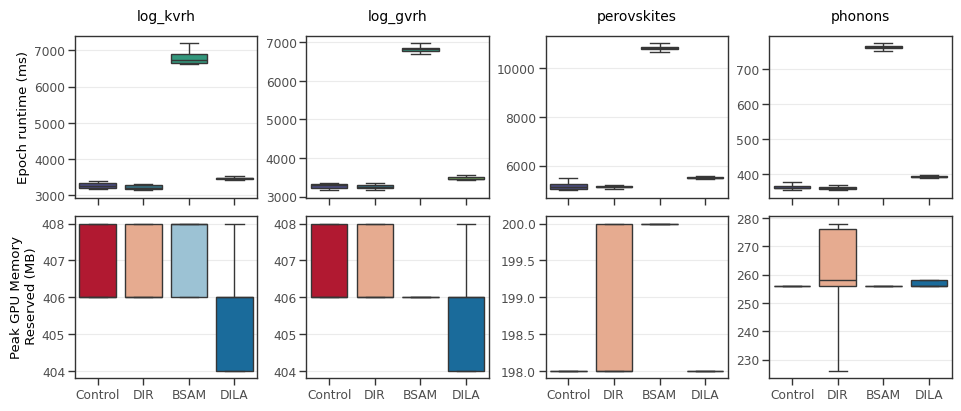

In [28]:
datasets = ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']
fig, (axes1, axes2) = plt.subplots(2,4, figsize = (9.5, 4), sharex = True, layout = 'compressed')
axes1 = axes1.flatten()
axes2 = axes2.flatten()
for dataset, ax1, ax2 in zip(datasets, axes1, axes2):
    combined_df = load_and_process_profiles(dataset, methods = ["Control", "DIR", "BSAM", "DILA"])
    # print_summary_table(combined_df)
    plot_epoch_time(combined_df, ax1)
    plot_gpu_usage(combined_df, ax2)
    ax1.set_title(dataset, loc = 'center', fontsize = 10)
    ax1.set_ylabel('')
    ax2.set_ylabel('')

axes1[0].set_ylabel('Epoch runtime (ms)')
axes2[0].set_ylabel('Peak GPU Memory\n Reserved (MB)')
# fig.supylabel("Epoch runtime (ms)", fontsize = 10)
plt.savefig('figs/paper_final/methods_profile.jpg', dpi = 600)

## Analysis: Alpha-SERA Transfer Mechanism

This section investigates why gains in distribution awareness ($\alpha$) do not always produce commensurate reductions in tail error (SERA), with particular focus on the `perovskites` dataset. Two primary mechanisms are identified:

1. **Saturation / ceiling effect** -- the baseline Control model already operates at $\alpha \approx 0.84$ on `perovskites`, versus $\approx 0.66$ for `log_kvrh` and $\approx 0.60$ for `phonons`. DILA's marginal gain ($\Delta \alpha \approx +0.008$) is too small to shift SERA meaningfully.

2. **Flat $\alpha$-SERA slope at high $\alpha$** -- conditional binned analysis shows that once $\alpha \gtrsim 0.80$ the SERA response to further awareness gains is nearly flat for `perovskites`, so even a larger gain would yield negligible tail-error reduction.

**Correction to earlier analysis (CV artefact):** An initial claim that perovskites SERA is "noise-dominated" (based on epoch-pooled CV $\approx$ 2.9 vs $>$100 for other datasets) is incorrect. CV = std/mean is scale-invariant, so the mean SERA value is not the cause. Instead, the large CV for `log_kvrh`, `log_gvrh`, and `phonons` is inflated by early-epoch SERA transients and a small fraction of diverged runs (5-8% filtered), while `perovskites` has zero diverged runs and smooth early convergence. At model convergence (final epoch), all three non-phonons datasets have near-identical run-level CV ($\approx 0.32$-$0.37$) and IQR/median ($\approx 0.46$-$0.52$). The robust $\log_{10}$(SERA) standard deviation is also comparable or larger for perovskites (0.14) than for `log_gvrh` (0.14) and `log_kvrh` (0.16). Perovskites is therefore not distinguishable from the moduli datasets in terms of intrinsic SERA noise.

Panel (j) of the figure below visualises this artefact directly: the epoch-pooled CV (grey bars, log scale) diverges wildly across datasets, while the robust IQR/median at final epoch (coloured bars) is comparable for `log_kvrh`, `log_gvrh`, and `perovskites`.

**Requires:** `filter_outlier_runs` defined in the *Fig 2 Training Trajectory* cell.

*`_BASE_DIR` now points at the MatFold archive, which holds val_logs for every method (the CV archive keeps trajectories for DILA only).*

In [29]:
# ===================================================================
# ALPHA-SERA TRANSFER: Data loading (revised)
# Reuses filter_outlier_runs() defined in the 'Fig 2' cell above.
# ===================================================================
import os, glob
from collections import defaultdict
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

_BASE_DIR  = "experiments/matfold"
_DATASETS  = ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']
_DS_LABELS = {
    'log_kvrh':    r"$\log(K_{\mathrm{vrh}})$",
    'log_gvrh':    r"$\log(G_{\mathrm{vrh}})$",
    'perovskites': "Perovskites",
    'phonons':     "Phonons",
}
_DS_COLORS = {
    'log_kvrh':    '#e41a1c',
    'log_gvrh':    '#377eb8',
    'perovskites': '#4daf4a',
    'phonons':     '#984ea3',
}
_METHODS = ['control', 'dir', 'bsam', 'smooth_dila']
# Method styling mapped 1:1 from compare_mae_wb (manuscript theme):
#   color -> line / marker edge (e_colors);  fill -> light marker face (f_colors)
_MSTYLE  = {
    'control':     {'label': 'Control', 'color': '#4d4d4d', 'fill': '#e0e0e0', 'marker': 's'},
    'dir':         {'label': 'DIR',     'color': '#2166ac', 'fill': '#d1e5f0', 'marker': 'o'},
    'bsam':        {'label': 'BSAM',    'color': '#b2182b', 'fill': '#fff5eb', 'marker': '^'},
    'smooth_dila': {'label': 'DILA',    'color': '#35978f', 'fill': '#c7eae5', 'marker': 'v'},
}
_ALPHA_BINS = np.linspace(0.30, 0.99, 16)
_TAIL_N     = 75   # epochs per run for converged-basin scatter


def _load_method_transfer(dataset, method, warmup=20, base_dir=None):
    """Load and filter val_log CSVs for one dataset/method combination.

    base_dir defaults to _BASE_DIR (MatFold); pass "experiments/final" for CV."""
    base_dir = base_dir or _BASE_DIR
    pattern = os.path.join(base_dir, dataset, method, "fold_*_run*_val_log.csv")
    files   = glob.glob(pattern)
    if not files:
        return pd.DataFrame()

    fold_files = defaultdict(list)
    for f in files:
        fn = os.path.basename(f)
        try:
            fid = fn.split("fold_")[1].split("_")[0]
        except Exception:
            fid = "unk"
        fold_files[fid].append(f)

    all_dfs = []
    for fid, flist in fold_files.items():
        raw = []
        for f in flist:
            try:
                df = pd.read_csv(f)
                df['_fold'] = fid
                df['_run']  = os.path.basename(f)
                if len(df) > warmup + 5:
                    raw.append(df)
            except Exception:
                pass
        # filter_outlier_runs is defined in the 'Fig 2 Training Trajectory' cell
        valid = filter_outlier_runs(raw, method, fid, metric='mae', warmup_epochs=warmup)
        all_dfs.extend(valid)

    if not all_dfs:
        return pd.DataFrame()

    combined = pd.concat(all_dfs, ignore_index=True)
    combined['dataset']      = dataset
    combined['method']       = method
    combined['method_label'] = _MSTYLE.get(method, {}).get('label', method)
    combined['log_sera']     = np.log10(combined['sera'].clip(lower=1e-6))
    return combined


def _spearman(df, x='awareness', y='sera'):
    """Spearman rho between alpha and raw SERA over finite rows."""
    if df.empty or x not in df.columns or y not in df.columns:
        return np.nan
    df2 = df.dropna(subset=[x, y])
    df2 = df2[np.isfinite(df2[y]) & np.isfinite(df2[x])]
    if len(df2) < 10:
        return np.nan
    rho, _ = stats.spearmanr(df2[x], df2[y])
    return rho


print(f"Loading filtered data from {_BASE_DIR}/ ...")
_DATA = {}
for ds in _DATASETS:
    _DATA[ds] = {}
    for m in _METHODS:
        df = _load_method_transfer(ds, m)
        _DATA[ds][m] = df
        n_runs = df['_run'].nunique() if not df.empty else 0
        print(f"  {ds:12s} / {m:20s}: {n_runs:2d} valid runs, {len(df):6d} epoch-rows")
print("Done.\n")

# ── Build final-epoch SERA records (one row per converged run) ──
_FINAL_SERA = {}   # ds -> pd.Series of log10(SERA) at last epoch, all methods pooled
for ds in _DATASETS:
    vals = []
    for m in _METHODS:
        df = _DATA[ds][m]
        if df.empty:
            continue
        fin = (df.sort_values('epoch')
                 .groupby(['_fold', '_run'])
                 .last()
                 .reset_index())
        fin_s = fin['sera'].dropna()
        fin_s = fin_s[fin_s > 0]
        vals.extend(fin_s.values)
    _FINAL_SERA[ds] = np.array(vals)

# ── Print corrected dispersion comparison ──
print("SERA dispersion: raw epoch-pooled CV vs robust run-level measures (all methods pooled)")
print(f"{'Dataset':<14} {'%_runs_filtered':>16}  {'CV(all epochs)':>15}  "
      f"{'IQR/med(all epochs)':>20}  {'CV(final epoch)':>16}  "
      f"{'IQR/med(final)':>15}  {'log10_std(final)':>17}")
print("-" * 110)
for ds in _DATASETS:
    # Count filtered runs
    total_raw, total_filt = 0, 0
    for m in _METHODS:
        pattern = os.path.join(_BASE_DIR, ds, m, "fold_*_run*_val_log.csv")
        files = glob.glob(pattern)
        total_raw += len(files)
        total_filt += _DATA[ds][m]['_run'].nunique() if not _DATA[ds][m].empty else 0
    pct_filtered = (total_raw - total_filt) / total_raw * 100 if total_raw > 0 else 0

    # CV on all pooled epochs
    all_s = pd.concat([_DATA[ds][m]['sera'].dropna()
                        for m in _METHODS if not _DATA[ds][m].empty])
    all_s = all_s[all_s > 0].values
    cv_all = all_s.std() / all_s.mean()
    q1, med, q3 = np.percentile(all_s, [25, 50, 75])
    iqr_all = (q3 - q1) / med

    # Run-level final-epoch stats
    s = _FINAL_SERA[ds]
    cv_fin   = s.std() / s.mean()
    q1f, medf, q3f = np.percentile(s, [25, 50, 75])
    iqr_fin  = (q3f - q1f) / medf
    log10_std = np.log10(s).std()

    print(f"  {ds:<12} {pct_filtered:>16.1f}%  {cv_all:>15.2f}  "
          f"{iqr_all:>20.3f}  {cv_fin:>16.3f}  {iqr_fin:>15.3f}  {log10_std:>17.3f}")

print()
print("Key finding: raw epoch-pooled CV is inflated by early-epoch SERA transients and diverged")
print("runs in log_kvrh/log_gvrh/phonons.  At final epoch (converged), CV is 0.32-0.37 for all")
print("non-phonons datasets -- perovskites is NOT noise-dominated by this measure.")
print("The robust IQR/median and log10_std also confirm comparable dispersion.")

Loading filtered data from experiments/matfold/ ...
  log_kvrh     / control             : 26 valid runs,  13000 epoch-rows
  log_kvrh     / dir                 : 25 valid runs,  12500 epoch-rows
  log_kvrh     / bsam                : 28 valid runs,  14000 epoch-rows
  log_kvrh     / smooth_dila         : 25 valid runs,  12500 epoch-rows
  log_gvrh     / control             : 19 valid runs,   9500 epoch-rows
  log_gvrh     / dir                 : 25 valid runs,  12500 epoch-rows
  log_gvrh     / bsam                : 25 valid runs,  12500 epoch-rows
  log_gvrh     / smooth_dila         : 25 valid runs,  12500 epoch-rows
  perovskites  / control             : 25 valid runs,  12500 epoch-rows
  perovskites  / dir                 : 25 valid runs,  12500 epoch-rows
  perovskites  / bsam                : 25 valid runs,  12500 epoch-rows
  perovskites  / smooth_dila         : 25 valid runs,  12500 epoch-rows
  phonons      / control             : 24 valid runs,  12000 epoch-rows
  phonons   

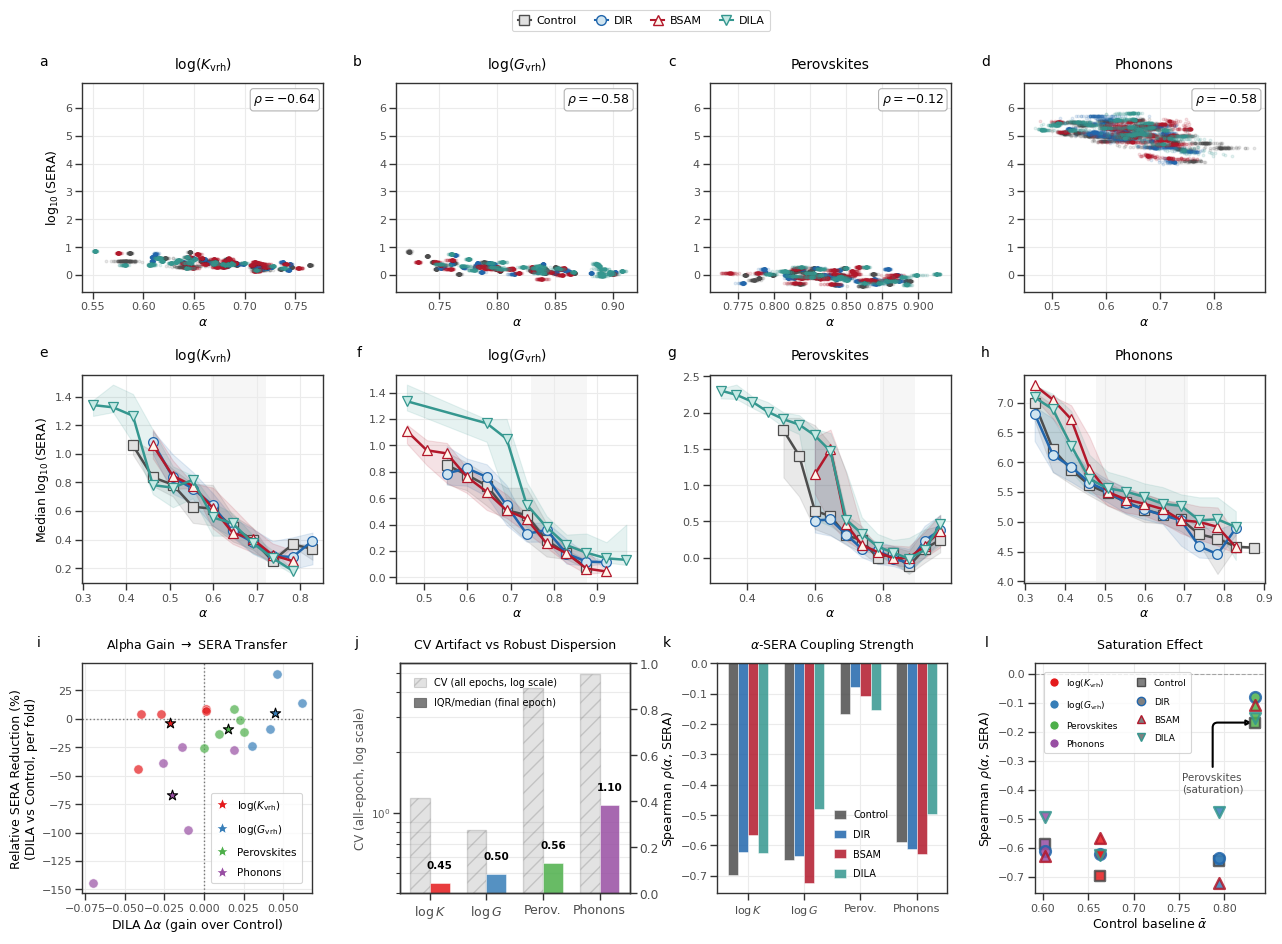

In [30]:
# ===================================================================
# FIGURE (revised): Alpha-SERA Transfer Mechanism
#
# Row 1 (a-d): Scatter of alpha vs log10(SERA) for converged basins
#              (last 75 epochs per run). Spearman rho annotated.
# Row 2 (e-h): Conditional median log10(SERA) per alpha-bin (IQR band).
#              Grey band = 10th-90th pct operating window of alpha.
# Row 3 (i-l): Four summary panels
#   (i) DILA alpha-gain vs relative SERA reduction per fold / dataset
#   (j) Epoch-pooled CV vs run-level final-epoch CV: shows the artifact
#   (k) Spearman rho per dataset / method (grouped bars)
#   (l) Control baseline alpha vs coupling strength (saturation scatter)
# ===================================================================
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(13, 10))
gs_top = gridspec.GridSpec(
    2, 4, figure=fig,
    hspace=0.40, wspace=0.30,
    top=0.88, bottom=0.38, left=0.07, right=0.98
)
gs_bot = gridspec.GridSpec(
    1, 4, figure=fig,
    hspace=0.30, wspace=0.38,
    top=0.30, bottom=0.07, left=0.07, right=0.98
)

ax_scatter    = [fig.add_subplot(gs_top[0, i]) for i in range(4)]
ax_cond       = [fig.add_subplot(gs_top[1, i]) for i in range(4)]
ax_transfer   = fig.add_subplot(gs_bot[0, 0])   # (i) DILA gain vs SERA red.
ax_cv_compare = fig.add_subplot(gs_bot[0, 1])   # (j) CV artifact panel (NEW)
ax_coupling   = fig.add_subplot(gs_bot[0, 2])   # (k) Spearman rho bars
ax_saturation = fig.add_subplot(gs_bot[0, 3])   # (l) Saturation scatter


# Per-method colours / markers come from _MSTYLE (compare_mae_wb theme):
#   Control  s  #4d4d4d   DIR  o  #2166ac   BSAM  ^  #b2182b   DILA  v  #35978f


def _ds_label_short(ds):
    return {
        'log_kvrh':    r"$\log K$",
        'log_gvrh':    r"$\log G$",
        'perovskites': "Perov.",
        'phonons':     "Phonons"
    }.get(ds, ds)

# =====================================================================
# ROWS 1-2: per-dataset panels (unchanged)
# =====================================================================
for col, ds in enumerate(_DATASETS):

    # -- Row 1: alpha vs log(SERA) scatter (last _TAIL_N converged epochs) --
    ax = ax_scatter[col]
    for m in _METHODS:
        df = _DATA[ds][m]
        if df.empty:
            continue
        tail  = (df.sort_values('epoch')
                   .groupby(['_fold', '_run'], group_keys=False)
                   .tail(_TAIL_N))
        tail2 = tail.dropna(subset=['awareness', 'log_sera'])
        tail2 = tail2[np.isfinite(tail2['log_sera'])]
        st    = _MSTYLE[m]
        ax.scatter(tail2['awareness'], tail2['log_sera'],
                   color=st['color'], s=4, alpha=0.12, rasterized=True)

    pool     = pd.concat([_DATA[ds][m] for m in _METHODS
                          if not _DATA[ds][m].empty], ignore_index=True)
    rho_pool = _spearman(pool)
    ax.text(0.97, 0.96,
            f"$\\rho = {rho_pool:.2f}$",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.25', fc='white',
                      ec='#aaaaaa', alpha=0.9))

    ax.set_title(_DS_LABELS[ds], fontsize=10, loc='center')
    ax.set_xlabel(r"$\alpha$", fontsize=9)
    if col == 0:
        ax.set_ylabel(r"$\log_{10}(\mathrm{SERA})$", fontsize=9)
    ax.tick_params(labelsize=8)
    add_panel_label(ax, col, loc=(-0.14, 1.14))

    # -- Row 2: conditional log(SERA) vs alpha bin --
    ax2         = ax_cond[col]
    bin_centers = (_ALPHA_BINS[:-1] + _ALPHA_BINS[1:]) / 2

    for m in _METHODS:
        df = _DATA[ds][m]
        if df.empty:
            continue
        df2            = df.dropna(subset=['awareness', 'log_sera'])
        df2            = df2[np.isfinite(df2['log_sera'])]
        st             = _MSTYLE[m]
        meds, q1s, q3s, xs = [], [], [], []
        for lo, hi, cx in zip(_ALPHA_BINS[:-1], _ALPHA_BINS[1:], bin_centers):
            sub = df2[(df2['awareness'] >= lo) & (df2['awareness'] < hi)]
            if len(sub) >= 8:
                meds.append(sub['log_sera'].median())
                q1s.append(sub['log_sera'].quantile(0.25))
                q3s.append(sub['log_sera'].quantile(0.75))
                xs.append(cx)
        if len(xs) > 1:
            ax2.plot(xs, meds, color=st['color'], lw=1.8,
                     marker=st['marker'], ms=7.0,
                     mfc=st.get('fill', st['color']), mec=st['color'], mew=0.9)
            ax2.fill_between(xs, q1s, q3s, color=st['color'], alpha=0.12)

    all_alpha = pd.concat([_DATA[ds][m]['awareness'].dropna()
                           for m in _METHODS
                           if not _DATA[ds][m].empty])
    ax2.axvspan(all_alpha.quantile(0.10), all_alpha.quantile(0.90),
                alpha=0.07, color='#888888', lw=0, zorder=0)

    ax2.set_xlabel(r"$\alpha$", fontsize=9)
    if col == 0:
        ax2.set_ylabel(r"Median $\log_{10}(\mathrm{SERA})$", fontsize=9)
    ax2.tick_params(labelsize=8)
    ax2.set_title(_DS_LABELS[ds], fontsize=10, loc='center')
    add_panel_label(ax2, col + 4, loc=(-0.14, 1.14))

# Clip Row 1 y-range to consistent window
all_ls   = pd.concat([_DATA[ds][m]['log_sera'].dropna()
                       for ds in _DATASETS for m in _METHODS
                       if not _DATA[ds][m].empty])
y1_lo, y1_hi = all_ls.quantile(0.01), all_ls.quantile(0.99)
for ax in ax_scatter:
    ax.set_ylim(y1_lo - 0.3, y1_hi + 0.3)

# =====================================================================
# ROW 3a (i): DILA alpha-gain vs SERA reduction (unchanged)
# =====================================================================
for ds in _DATASETS:
    ctrl_df = _DATA[ds]['control']
    dila_df = _DATA[ds]['smooth_dila']
    if ctrl_df.empty or dila_df.empty:
        continue

    ctrl_fin = (ctrl_df.groupby(['_fold', '_run']).last()
                       .groupby('_fold')
                       .agg({'awareness': 'mean', 'sera': 'mean'}))
    dila_fin = (dila_df.groupby(['_fold', '_run']).last()
                        .groupby('_fold')
                        .agg({'awareness': 'mean', 'sera': 'mean'}))
    common = ctrl_fin.index.intersection(dila_fin.index)
    if common.empty:
        continue

    alpha_gains = (dila_fin.loc[common, 'awareness'] -
                   ctrl_fin.loc[common, 'awareness'])
    sera_reds   = ((ctrl_fin.loc[common, 'sera'] -
                    dila_fin.loc[common, 'sera']) /
                   ctrl_fin.loc[common, 'sera'] * 100)

    c = _DS_COLORS[ds]
    ax_transfer.scatter(alpha_gains, sera_reds,
                        color=c, s=45, alpha=0.70,
                        edgecolors='white', lw=0.5, zorder=5)
    ag_mu = alpha_gains.mean()
    sr_mu = sera_reds.mean()
    ax_transfer.scatter(ag_mu, sr_mu,
                        color=c, s=60, marker='*',
                        edgecolors='black', lw=0.8, zorder=10)
    # ax_transfer.annotate(
    #     _DS_LABELS[ds],
    #     xy=(ag_mu, sr_mu),
    #     xytext=(5, 3), textcoords='offset points',
    #     fontsize=8, color=c, fontweight='bold'
    # )

ax_transfer.axhline(0, color='k', lw=1.0, ls=':', alpha=0.5)
ax_transfer.axvline(0, color='k', lw=1.0, ls=':', alpha=0.5)
ax_transfer.set_xlabel(r"DILA $\Delta\alpha$ (gain over Control)", fontsize=9)
ax_transfer.set_ylabel("Relative SERA Reduction (%)\n(DILA vs Control, per fold)", fontsize=9)
ax_transfer.set_title(r"Alpha Gain $\rightarrow$ SERA Transfer", fontsize=9, loc='center')
ax_transfer.tick_params(labelsize=8)
add_panel_label(ax_transfer, 8, loc=(-0.18, 1.12))

ds_handles_bot = [
    Line2D([0], [0], marker='*', color='w',
           markerfacecolor=_DS_COLORS[ds],
           markersize=10, label=_DS_LABELS[ds])
    for ds in _DATASETS
]
ax_transfer.legend(handles=ds_handles_bot, fontsize=7.5,
                   loc='lower right', frameon=True)

# =====================================================================
# ROW 3b (j): CV artifact panel -- epoch-pooled CV vs final-epoch CV
# NEW panel: directly shows why raw CV is misleading for perovskites
# =====================================================================
x_pos  = np.arange(len(_DATASETS))
xticks = [_ds_label_short(ds) for ds in _DATASETS]
bar_w  = 0.35

# Epoch-pooled CV (includes early-epoch transients and diverged runs)
cv_pooled = []
for ds in _DATASETS:
    all_s = pd.concat([_DATA[ds][m]['sera'].dropna()
                        for m in _METHODS if not _DATA[ds][m].empty])
    all_s = all_s[all_s > 0].values
    cv_pooled.append(all_s.std() / all_s.mean())

# Run-level final-epoch IQR/median (robust, outlier-free)
iqr_final = []
for ds in _DATASETS:
    s = _FINAL_SERA[ds]
    s = s[s > 0]
    q1, med, q3 = np.percentile(s, [25, 50, 75])
    iqr_final.append((q3 - q1) / med)

# Log10-std at final epoch (scale-free, robust)
log10_std_final = []
for ds in _DATASETS:
    s = _FINAL_SERA[ds]
    s = s[s > 0]
    log10_std_final.append(np.log10(s).std())

# Left y-axis: epoch-pooled CV (log scale)
ax_cv2 = ax_cv_compare.twinx()

# --- REVISED: b1 uses a light/transparent fill with diagonal hatching ---
b1 = ax_cv_compare.bar(x_pos - bar_w/2, cv_pooled, width=bar_w,
                        facecolor='#8c8c8c', alpha=0.25, hatch='//',
                        edgecolor='#666666', lw=1.0, label='CV (all epochs)')

b2 = ax_cv_compare.bar(x_pos + bar_w/2, iqr_final, width=bar_w,
                        color=[_DS_COLORS[ds] for ds in _DATASETS],
                        alpha=0.85, label='IQR/median (final epoch)',
                        edgecolor='white', lw=0.4)

ax_cv_compare.set_yscale('log')
ax_cv_compare.set_xticks(x_pos)
ax_cv_compare.set_xticklabels(xticks, fontsize=9)
ax_cv_compare.set_ylabel("CV (all-epoch, log scale)", fontsize=8.5,
                          color='#555555')
ax_cv_compare.tick_params(axis='y', labelcolor='#555555', labelsize=7.5)
ax_cv_compare.tick_params(axis='x', labelsize=9)

ax_cv2.grid(False)
ax_cv_compare.grid(False)

# Annotate the robust IQR values on the coloured bars
for xi, iqr in zip(x_pos, iqr_final):
    ax_cv_compare.text(xi + bar_w/2, iqr * 1.15, f"{iqr:.2f}",
                       ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax_cv_compare.set_title("CV Artifact vs Robust Dispersion", fontsize=9, loc='center')

# --- REVISED: Updated legend patches to match the new bar styling ---
legend_handles_cv = [
    mpatches.Patch(facecolor='#8c8c8c', alpha=0.25, edgecolor='#666666', hatch='//', 
                   label='CV (all epochs, log scale)'),
    mpatches.Patch(color='#666666', alpha=0.85, 
                   label='IQR/median (final epoch)'),
]
ax_cv_compare.legend(handles=legend_handles_cv, fontsize=7, loc='upper left')
add_panel_label(ax_cv_compare, 9, loc=(-0.18, 1.12))

# =====================================================================
# ROW 3c (k): Spearman rho per dataset / method (grouped bars)
# =====================================================================
n_ds  = len(_DATASETS)
x_ds  = np.arange(n_ds)
n_mth = len(_METHODS)
w     = 0.18

for mi, m in enumerate(_METHODS):
    st   = _MSTYLE[m]
    rhos = [_spearman(_DATA[ds][m]) for ds in _DATASETS]
    offs = (mi - (n_mth - 1) / 2) * w
    ax_coupling.bar(x_ds + offs, rhos,
                    width=w, color=st['color'], label=st['label'],
                    edgecolor='white', lw=0.4, alpha=0.85)

ax_coupling.axhline(0, color='k', lw=0.8)
ax_coupling.set_xticks(x_ds)
ax_coupling.set_xticklabels(xticks, fontsize=9)
ax_coupling.set_ylabel(r"Spearman $\rho$($\alpha$, SERA)", fontsize=9)
ax_coupling.set_title(r"$\alpha$-SERA Coupling Strength", fontsize=9, loc='center')
ax_coupling.legend(fontsize=7, bbox_to_anchor=(0.625,0), loc='lower center', ncol=1)
ax_coupling.tick_params(labelsize=8)
add_panel_label(ax_coupling, 10, loc=(-0.20, 1.12))

# =====================================================================
# ROW 3d (l): Control baseline alpha vs Spearman coupling (saturation)
# =====================================================================
for ds in _DATASETS:
    ctrl_df = _DATA[ds]['control']
    if ctrl_df.empty:
        continue
    baseline_alpha = ctrl_df['awareness'].mean()

    for m in _METHODS:
        df  = _DATA[ds][m]
        rho = _spearman(df)
        st  = _MSTYLE[m]
        ax_saturation.scatter(
            baseline_alpha, rho,
            color=_DS_COLORS[ds],
            marker=st['marker'],
            s=60, alpha=0.85,
            edgecolors=st['color'],
            lw=1.75, zorder=5
        )

pv_alpha = _DATA['perovskites']['control']['awareness'].mean()
pv_rho   = _spearman(_DATA['perovskites']['control'])
ax_saturation.annotate(
    "Perovskites\n(saturation)", 
    xy=(pv_alpha, pv_rho), 
    xytext=(pv_alpha - 0.08, pv_rho - 0.24), 
    fontsize=7.5, 
    color="#4d4d4d", 
    arrowprops=dict(
        arrowstyle="-|>", 
        connectionstyle="angle,angleA=-90,angleB=180,rad=5", 
        lw=1.5, fc='#e0e0e0'
    ), 
)

ax_saturation.axhline(0, color='k', lw=0.8, ls='--', alpha=0.3)
ax_saturation.set_xlabel(r"Control baseline $\bar{\alpha}$", fontsize=9)
ax_saturation.set_ylabel(r"Spearman $\rho$($\alpha$, SERA)", fontsize=9)
ax_saturation.set_title("Saturation Effect", fontsize=9, loc='center')
ax_saturation.tick_params(labelsize=8)
add_panel_label(ax_saturation, 11, loc=(-0.20, 1.12))

ds_leg = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=_DS_COLORS[ds], markersize=7, label=_DS_LABELS[ds])
    for ds in _DATASETS
]
m_leg = [
    Line2D([0], [0],
           marker=_MSTYLE[m]['marker'], color='grey',
           markeredgecolor=_MSTYLE[m]['color'],
           markersize=6, lw=0, label=_MSTYLE[m]['label'])
    for m in _METHODS
]
ax_saturation.legend(handles=ds_leg + m_leg, fontsize=6.5,
                     loc='upper left', ncol=2, frameon=True)

# ── Global method legend spanning all top columns ──
method_handles_global = [
    Line2D([0], [0],
           marker=_MSTYLE[m]['marker'], color=_MSTYLE[m]['color'],
           mfc=_MSTYLE[m].get('fill', _MSTYLE[m]['color']), mec=_MSTYLE[m]['color'],
           ms=7, lw=1.5, label=_MSTYLE[m]['label'])
    for m in _METHODS
]

fig.legend(
    handles=method_handles_global,
    loc='upper center', ncols=4, fontsize=8,
    bbox_to_anchor=(0.5, 0.965), frameon=True,
    columnspacing=1.6, handletextpad=0.5
)

# fig.suptitle(
#     r"Alpha-SERA Transfer: Saturation and Flat Coupling are the Primary Mechanisms",
#     fontsize=11, fontweight='bold', y=1.00
# )

os.makedirs('figs/paper_final', exist_ok=True)
plt.savefig(
    'figs/paper_final/alpha_sera_transfer_analysis.jpg',
    dpi=300, bbox_inches='tight'
)
plt.show()
# print("Saved -> figs/paper_final/alpha_sera_transfer_analysis.jpg")


## SI tables: $\alpha$--SERA coupling (Tables SI3/SI4) and coupling vs Stage-1 descriptors (Table SI5)

Generated from the **same pipeline as the transfer figure above** (filtered val-log
trajectories; correlations between awareness $\alpha$ and validation SERA over the
full trajectories; Pearson on $\log_{10}$ SERA, Spearman/Kendall rank-based), so the SI tables and the figure panels agree by construction.
CV trajectories load from `experiments/final` via the `base_dir` override; entries
without archived val logs (phonons CV DIR/BSAM) are emitted as `--`.
Replaces the retired `Platform_figs.ipynb` `coupling_table`/`coupling_vs_imbalance` outputs.

Outputs: `alpha_sera_correlation.csv`, `alpha_sera_correlation_{cv,matfold}.txt`
(LaTeX bodies for Tables SI3/SI4), `coupling_vs_imbalance.csv`,
`coupling_vs_imbalance_table.txt` (LaTeX body for Table SI5).

In [31]:
# ===================================================================
# SI TABLES: alpha-SERA coupling (SI3/SI4) + coupling vs Stage-1
# descriptors (SI5). Same estimator as panel (k) of the transfer
# figure: correlations of (awareness, raw SERA) over the full
# filtered trajectories.
# ===================================================================
from scipy.stats import pearsonr, spearmanr, kendalltau

print("Loading filtered CV trajectory data from experiments/final/ ...")
_DATA_CV = {}
for ds in _DATASETS:
    _DATA_CV[ds] = {}
    for m in _METHODS:
        df = _load_method_transfer(ds, m, base_dir="experiments/final")
        _DATA_CV[ds][m] = df
        n_runs = df['_run'].nunique() if not df.empty else 0
        print(f"  {ds:12s} / {m:20s}: {n_runs:2d} valid runs, {len(df):6d} epoch-rows")

_SPLIT_DATA = {"cv": _DATA_CV, "matfold": _DATA}
_DS_TEX = {'log_kvrh': r'\texttt{log\_kvrh}', 'log_gvrh': r'\texttt{log\_gvrh}',
           'perovskites': r'\texttt{perovskites}', 'phonons': r'\texttt{phonons}'}


def _corr3(df, x='awareness', y='sera'):
    """(Pearson, Spearman, Kendall) between alpha and SERA; NaN if <10 rows.

    Pearson is computed on log10(SERA) — raw SERA spans orders of magnitude,
    so a handful of extreme epochs would otherwise dominate the linear
    estimator. Spearman/Kendall are rank-based and invariant to the log
    transform, so they equal the raw-SERA values (and panel k above)."""
    if df.empty or x not in df.columns or y not in df.columns:
        return (np.nan,) * 3
    d = df.dropna(subset=[x, y])
    d = d[np.isfinite(d[x]) & np.isfinite(d[y]) & (d[y] > 0)]
    if len(d) < 10:
        return (np.nan,) * 3
    return (pearsonr(d[x], np.log10(d[y]))[0], spearmanr(d[x], d[y])[0],
            kendalltau(d[x], d[y])[0])


rows = []
for split, data in _SPLIT_DATA.items():
    for ds in _DATASETS:
        for m in _METHODS:
            p, s, k = _corr3(data[ds][m])
            rows.append(dict(experiment=split, dataset=ds,
                             method=_MSTYLE[m]['label'],
                             n_rows=len(data[ds][m]),
                             pearson=p, spearman=s, kendall=k))
        nonempty = [data[ds][m] for m in _METHODS if not data[ds][m].empty]
        pooled = pd.concat(nonempty, ignore_index=True) if nonempty else pd.DataFrame()
        p, s, k = _corr3(pooled)
        rows.append(dict(experiment=split, dataset=ds, method='pooled',
                         n_rows=len(pooled), pearson=p, spearman=s, kendall=k))
coupling_df = pd.DataFrame(rows)
coupling_df.to_csv("figs/paper_final/alpha_sera_correlation.csv", index=False)


def _fmt(v):
    return "--" if not np.isfinite(v) else f"${v:.3f}$"


for split in ("cv", "matfold"):
    lines = []
    for ds in _DATASETS:
        sub = coupling_df[(coupling_df.experiment == split)
                          & (coupling_df.dataset == ds)
                          & (coupling_df.method != 'pooled')]
        for i, (_, r) in enumerate(sub.iterrows()):
            lead = _DS_TEX[ds] if i == 0 else ' '
            lines.append(f"{lead} & {r.method} & {_fmt(r.pearson)} & "
                         f"{_fmt(r.spearman)} & {_fmt(r.kendall)} \\\\")
        if ds != _DATASETS[-1]:
            lines.append(r"\midrule")
    out = f"figs/paper_final/alpha_sera_correlation_{split}.txt"
    with open(out, "w") as f:
        f.write("\n".join(lines) + "\n")
    print("Saved ->", out)

print("\nMethod-pooled Spearman rho (quoted in main text Section 4):")
print(coupling_df[coupling_df.method == 'pooled']
      [["experiment", "dataset", "n_rows", "spearman"]]
      .round(3).to_string(index=False))

# --- Table SI5: coupling strength vs Stage-1 descriptors -----------
# Coupling strength per dataset = mean |Spearman| over methods and both
# split types; descriptors from the Stage-1 result_df (Fig 1 cell).
per_method = (coupling_df[coupling_df.method != 'pooled']
              .dropna(subset=['spearman']))
strength = per_method.groupby("dataset")["spearman"].apply(
    lambda s: np.abs(s).mean())

_DESC_COLS = {"$h$": "DIL", "$G$": "Gini",
              "$D_{KL}$": "KL_Div", "$W_1$": "Wasserstein"}
prof = result_df.set_index("dataset")
cvi_rows, tex_lines = [], []
for tex_name, col in _DESC_COLS.items():
    x = prof.loc[strength.index, col].astype(float)
    r, pval = pearsonr(x, strength.values)
    cvi_rows.append(dict(descriptor=col, pearson_r=r, p_value=pval,
                         n_datasets=len(strength)))
    tex_lines.append(f"{tex_name:9s} & ${r:.3f}$ & ${pval:.2f}$ & {len(strength)} \\\\")
cvi_df = pd.DataFrame(cvi_rows)
cvi_df.to_csv("figs/paper_final/coupling_vs_imbalance.csv", index=False)
with open("figs/paper_final/coupling_vs_imbalance_table.txt", "w") as f:
    f.write("\n".join(tex_lines) + "\n")
print("\nSaved -> figs/paper_final/coupling_vs_imbalance_table.txt")
cvi_df.round(3)


Loading filtered CV trajectory data from experiments/final/ ...
  log_kvrh     / control             : 22 valid runs,  11000 epoch-rows
  log_kvrh     / dir                 : 25 valid runs,  12500 epoch-rows
  log_kvrh     / bsam                : 28 valid runs,  14000 epoch-rows
  log_kvrh     / smooth_dila         : 25 valid runs,  12500 epoch-rows
  log_gvrh     / control             : 21 valid runs,  10500 epoch-rows
  log_gvrh     / dir                 : 24 valid runs,  12000 epoch-rows
  log_gvrh     / bsam                : 25 valid runs,  12500 epoch-rows
  log_gvrh     / smooth_dila         : 25 valid runs,  12500 epoch-rows
  perovskites  / control             : 25 valid runs,  12500 epoch-rows
  perovskites  / dir                 : 25 valid runs,  12500 epoch-rows
  perovskites  / bsam                : 25 valid runs,  12500 epoch-rows
  perovskites  / smooth_dila         : 25 valid runs,  12500 epoch-rows
  phonons      / control             : 22 valid runs,  11000 epoch-rows


,descriptor,pearson_r,p_value,n_datasets
0,DIL,0.152,0.848,4
1,Gini,0.072,0.928,4
2,KL_Div,0.197,0.803,4
3,Wasserstein,0.212,0.788,4


## Output manifest

In [32]:
for root, _, files in sorted(os.walk("figs/paper_final")):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f"{os.path.getsize(p) / 1e6:8.2f} MB  {p}")


    0.00 MB  figs/paper_final/alpha_sera_correlation.csv
    0.00 MB  figs/paper_final/alpha_sera_correlation_cv.txt
    0.00 MB  figs/paper_final/alpha_sera_correlation_matfold.txt
    0.75 MB  figs/paper_final/alpha_sera_transfer_analysis.jpg
    0.00 MB  figs/paper_final/combined_flatness_table.txt
    0.00 MB  figs/paper_final/comprehensive_metrics_cv.csv
    0.00 MB  figs/paper_final/comprehensive_metrics_matfold.csv
    0.00 MB  figs/paper_final/comprehensive_metrics_table_cv.txt
    0.00 MB  figs/paper_final/comprehensive_metrics_table_matfold.txt
    0.00 MB  figs/paper_final/coupling_vs_imbalance.csv
    0.00 MB  figs/paper_final/coupling_vs_imbalance_table.txt
    1.92 MB  figs/paper_final/discov_performance.jpg
    1.04 MB  figs/paper_final/log_gvrh_fold0_aggregated.jpg
    1.06 MB  figs/paper_final/log_gvrh_fold1_aggregated.jpg
    1.09 MB  figs/paper_final/log_gvrh_fold2_aggregated.jpg
    1.06 MB  figs/paper_final/log_gvrh_fold3_aggregated.jpg
    1.04 MB  figs/paper_fina